# Deng--Ginting Example 4 style transport on SPE10 permeability, Q1 CG

This notebook is a no-fracture source--sink benchmark on \(\Omega=(0,1)^2\), inspired by Deng--Ginting Example 4.  It keeps the SPE10 layer-20 permeability/grid from the MRST export, but replaces the boundary-pressure problem by

\[
-\nabla\cdot(\kappa\nabla p)=q_I\chi_{K_I}/|K_I|-q_P\chi_{K_P}/|K_P|,
\qquad p=0\quad\text{on }\partial\Omega.
\]

The source points are the Deng locations scaled from \((0,5)\times(0,1)\) to \((0,1)^2\): \(x_I=(0.2,0.4)\), \(x_P=(0.8,0.5)\).  The point sources are regularized as cell-integrated sources on the matching SPE10/MRST cells.  Transport uses clean boundary inflow \(S=0\), source concentration \(S_I=1\), and an explicit upwind Buckley--Leverett update on the Deng nodal dual control volumes \(C_z\).

Flux choices:

- `CG`: raw Q1 CG flux, averaged on transport-cell interfaces.
- `NLR`: Deng/Ginting local Q1 reconstruction on nodal dual control volumes.
- `CVFEM`: vertex-centred control-volume finite-element pressure solve on the same nodal dual mesh.
- `PINN`: optional pressure-gradient network reconstruction with harmonic face permeability.
- `MRST`: included only if a matching homogeneous-Dirichlet source--sink MRST export is loaded.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.io import loadmat
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False

    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

# Active CG/FEM order.  Q1 uses the classical vertex dual mesh; Q2 uses the
# midpoint-bounded Q2 nodal dual mesh for Deng/CVFEM/transport.
CG_ORDER = 2
RUN_CVFEM_SOLVE = True
RUN_DUAL_TRANSPORT = True

# Base SPE10 export: currently used for grid and permeability.  If a matching
# source-sink MRST export is added later, put it earlier in DATA_CANDIDATES.
DATA_CANDIDATES = [
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_deng_example4.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_sourcesink.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64.mat"),
]
DATA_FILE = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_FILE = candidate
        break
if DATA_FILE is None:
    for candidate in DATA_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.as_posix()}"))
        if matches:
            DATA_FILE = matches[0]
            break
if DATA_FILE is None or not DATA_FILE.exists():
    raise FileNotFoundError("Could not find an SPE10 layer-20 MRST export containing kappa_cell/kappa_grid.")

mrst = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)

if CG_ORDER == 2:
    FINE_MRST_CANDIDATES = [
        pathlib.Path("case3_ecmor/case3_mrst_export_spe10_q2_dualT.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_finep_dualT.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_fine128_wells.mat"),
    ]
elif CG_ORDER == 1:
    FINE_MRST_CANDIDATES = [
        pathlib.Path("case3_ecmor/case3_mrst_export_finep_dualT.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_fine128_wells.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_spe10_q2_dualT.mat"),
    ]
else:
    raise ValueError("CG_ORDER must be 1 or 2.")
FINE_MRST_FILE = None
for candidate in FINE_MRST_CANDIDATES:
    if candidate.exists():
        FINE_MRST_FILE = candidate
        break
if FINE_MRST_FILE is None:
    for candidate in FINE_MRST_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.as_posix()}"))
        if matches:
            FINE_MRST_FILE = matches[0]
            break
mrst_fine = loadmat(FINE_MRST_FILE, squeeze_me=True, struct_as_record=False) if FINE_MRST_FILE is not None else {}
MRST_FINE_AVAILABLE = bool(mrst_fine)


def _arr(key, dtype=float):
    if key not in mrst:
        raise KeyError(f"Missing MRST field {key!r}")
    return np.asarray(mrst[key], dtype=dtype)


def _meta_float(key, default=np.nan):
    if key not in mrst:
        return float(default)
    values = np.asarray(mrst[key]).reshape(-1)
    return float(values[0]) if values.size else float(default)


def _meta_str(key, default=""):
    return str(mrst.get(key, default))

xc_matrix = _arr("xc_matrix", float)
face_neighbors = _arr("face_neighbors", np.int64)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)
face_p1 = _arr("face_p1", float)
face_p2 = _arr("face_p2", float)
face_flux_mrst_export = _arr("face_flux", float).reshape(-1) if "face_flux" in mrst else None
p_matrix_mrst_export = _arr("p_matrix", float).reshape(-1) if "p_matrix" in mrst else None
face_is_boundary = _arr("face_is_boundary", bool).reshape(-1) if "face_is_boundary" in mrst else np.any(face_neighbors == 0, axis=1)
kappa_cell_mrst = _arr("kappa_cell", float).reshape(-1) if "kappa_cell" in mrst else None

nx, ny = np.asarray(mrst.get("meta_celldim", [64, 64]), dtype=int).reshape(-1) if "meta_celldim" in mrst else np.asarray([64, 64], dtype=int)
if int(xc_matrix.shape[0]) != int(nx * ny):
    n_guess = int(round(np.sqrt(xc_matrix.shape[0])))
    nx = ny = n_guess
physdim = np.asarray(mrst.get("meta_physdim", [1.0, 1.0]), dtype=float).reshape(-1)
if physdim.size < 2:
    physdim = np.array([1.0, 1.0], dtype=float)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", _meta_float("meta_PV", phi_matrix * float(np.prod(physdim))))
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)
SPE10_LAYER = _meta_float("meta_layer", 20.0)
SPE10_CONTRAST = _meta_float("meta_contrast", np.nan)

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])
hx = physdim[0] / nx
hy = physdim[1] / ny
h_est = min(hx, hy)
ncell = int(xc_matrix.shape[0])
cell_area = np.full(ncell, float(np.prod(physdim)) / ncell, dtype=float)
cell_pv = phi_matrix * cell_area

kappa_cell_dg0 = np.asarray(kappa_cell_mrst, dtype=float).reshape(-1)
if kappa_cell_dg0.size != ncell:
    raise ValueError(f"Expected one SPE10 permeability value per cell ({ncell}), got {kappa_cell_dg0.size}.")

# Deng Example 4, x-coordinate scaled from [0,5] to [0,1].  The delta sources
# are regularized as cell-integrated sources on the selected grid cells.
SOURCE_POINTS_REQUESTED = np.array([[0.2, 0.4], [0.8, 0.5]], dtype=float)
SOURCE_RATES = np.array([1.0, -5.0], dtype=float)  # + spill/injector, - leakage/producer
SOURCE_SATURATION = 1.0
BOUNDARY_INFLOW_S = 0.0  # clean external reservoir on any pressure-boundary inflow
# Short defaults keep reruns quick under the CFL restriction of the unit-square
# SPE10 scaling.  Add 0.5, 1.0, 2.0 here if you want the paper's later times.
TRANSPORT_T_VALUES = np.array([0.02, 0.05, 0.1], dtype=float)
TRANSPORT_CASE_KEY = "T0.05"
TRANSPORT_CLIP = True
TRANSPORT_USE_FIXED_DT = False
TRANSPORT_DT = 1.0e-4  # Optional paper-style fixed dt; CFL mode is safer here.

# Matching MRST reference is only valid if the export has the same homogeneous
# Dirichlet/source-sink setup.  The old boundary-driven SPE10 export is not used
# as a reference for this notebook.
_meta_joined = " ".join([_meta_str("README"), _meta_str("meta_bc"), _meta_str("meta_source")]).lower()
MRST_REFERENCE_AVAILABLE = (
    face_flux_mrst_export is not None
    and p_matrix_mrst_export is not None
    and ("homogeneous" in _meta_joined or "p=0 on all" in _meta_joined)
    and ("source" in _meta_joined or "sink" in _meta_joined or "deng" in _meta_joined or "injector" in _meta_joined)
)


def rect_cell_ids_from_points(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    return iy * nx + ix


def kappa_numpy(points):
    return kappa_cell_dg0[rect_cell_ids_from_points(points)]

source_cell_ids = rect_cell_ids_from_points(SOURCE_POINTS_REQUESTED)
source_rate_cell = np.zeros(ncell, dtype=float)
for cid, rate in zip(source_cell_ids, SOURCE_RATES):
    source_rate_cell[int(cid)] += float(rate)
source_density_cell = source_rate_cell / cell_area
source_rate_total = float(np.sum(source_rate_cell))
source_rate_positive = float(np.sum(np.maximum(source_rate_cell, 0.0)))
source_rate_negative = float(np.sum(np.minimum(source_rate_cell, 0.0)))
source_points_effective = xc_matrix[source_cell_ids]


def f_numpy(points):
    return source_density_cell[rect_cell_ids_from_points(points)]


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

print(f"Loaded {DATA_FILE}")
print(f"SPE10 grid: {nx} x {ny}, cells={ncell}, faces={len(face_neighbors)}")
print(f"SPE10 layer={SPE10_LAYER:.0f}, contrast={SPE10_CONTRAST:.6g}, PV={PV_matrix:.8e}")
print("Deng-style source/sink regularized on grid cells:")
for req, eff, cid, rate in zip(SOURCE_POINTS_REQUESTED, source_points_effective, source_cell_ids, SOURCE_RATES):
    print(f"  requested={req}, effective cell center={eff}, cell={int(cid)}, rate={rate:+.6e}")
print(f"  total source integral={source_rate_total:+.6e}, positive injection={source_rate_positive:.6e}, negative sink={source_rate_negative:.6e}")
print(f"MRST matching homogeneous-Dirichlet source-sink reference available: {MRST_REFERENCE_AVAILABLE}")
print(f"MRST fine-pressure / dual-transport reference available: {MRST_FINE_AVAILABLE}" + (f" ({FINE_MRST_FILE})" if MRST_FINE_AVAILABLE else ""))
if not MRST_REFERENCE_AVAILABLE:
    print("  Note: loaded MRST data are used for SPE10 grid/permeability only; old boundary-driven MRST flux/saturation are not compared.")


Loaded case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat
SPE10 grid: 64 x 64, cells=4096, faces=8320
SPE10 layer=20, contrast=nan, PV=1.00000000e+00
Deng-style source/sink regularized on grid cells:
  requested=[0.2 0.4], effective cell center=[0.1953125 0.3984375], cell=1612, rate=+1.000000e+00
  requested=[0.8 0.5], effective cell center=[0.8046875 0.5078125], cell=2099, rate=-5.000000e+00
  total source integral=-4.000000e+00, positive injection=1.000000e+00, negative sink=-5.000000e+00
MRST matching homogeneous-Dirichlet source-sink reference available: True
MRST fine-pressure / dual-transport reference available: True (case3_ecmor/case3_mrst_export_spe10_q2_dualT.mat)


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Q2 CG pressure solve
  pressure dofs: 16641, cell dofs: 9
  p range: [-7.094185e-01, +3.024702e-01]
  source integral sum_K int_K f dx = -4.00000000e+00
  source density range: [-2.048e+04, +4.096e+03]
  matched MRST pressure mean|e|=4.959e-03, max|e|=1.442e-01


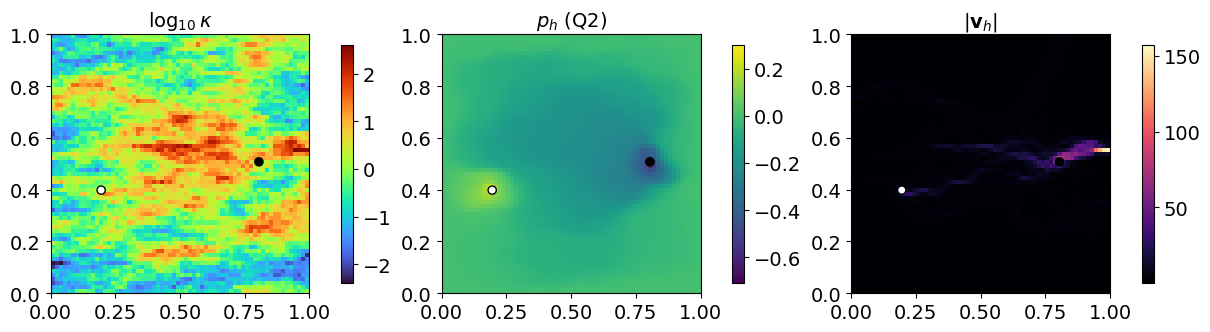

In [2]:
# Tensor-product CG pressure solve with homogeneous Dirichlet boundary and cell-regularized sources.
# Set CG_ORDER = 1 for Q1 or CG_ORDER = 2 for Q2 in the setup cell.
CG_ORDER = int(CG_ORDER)
if CG_ORDER not in (1, 2):
    raise ValueError("CG_ORDER must be 1 or 2 for this notebook.")


def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders
    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def tensor_lagrange_values_grads(order, xi_eta, hx_val=1.0, hy_val=1.0):
    xi_eta = np.asarray(xi_eta, dtype=float).reshape(-1, 2)
    nodes_1d = np.linspace(0.0, 1.0, int(order) + 1)
    Lx, dLx = lagrange_1d_values_and_derivatives(nodes_1d, xi_eta[:, 0])
    Ly, dLy = lagrange_1d_values_and_derivatives(nodes_1d, xi_eta[:, 1])
    nd = (int(order) + 1) ** 2
    vals = np.zeros((xi_eta.shape[0], nd), dtype=float)
    grads = np.zeros((xi_eta.shape[0], nd, 2), dtype=float)
    a = 0
    for j in range(int(order) + 1):
        for i in range(int(order) + 1):
            vals[:, a] = Lx[:, i] * Ly[:, j]
            grads[:, a, 0] = (dLx[:, i] / hx_val) * Ly[:, j]
            grads[:, a, 1] = Lx[:, i] * (dLy[:, j] / hy_val)
            a += 1
    return vals, grads


# Compatibility wrappers used by the Q1-only downstream cells.
def q1_phi(xi_eta):
    return tensor_lagrange_values_grads(1, xi_eta, 1.0, 1.0)[0]


def q1_grad_ref(xi_eta):
    return tensor_lagrange_values_grads(1, xi_eta, 1.0, 1.0)[1]


def q1_grad_phys(xi_eta, hx_val, hy_val):
    return tensor_lagrange_values_grads(1, xi_eta, hx_val, hy_val)[1]


nodes_per_axis_x = nx * CG_ORDER + 1
nodes_per_axis_y = ny * CG_ORDER + 1


def _nid(i, j):
    return j * nodes_per_axis_x + i


x_nodes = np.linspace(xmin, xmax, nodes_per_axis_x)
y_nodes = np.linspace(ymin, ymax, nodes_per_axis_y)
Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="xy")
fem_nodes = np.column_stack([Xn.ravel(), Yn.ravel()])
n_nodes = fem_nodes.shape[0]

quad_nodes = []
quad_polys = []
for j in range(ny):
    for i in range(nx):
        loc = []
        for jj in range(CG_ORDER + 1):
            for ii in range(CG_ORDER + 1):
                loc.append(_nid(i * CG_ORDER + ii, j * CG_ORDER + jj))
        quad_nodes.append(loc)
        x0, x1 = xmin + i * hx, xmin + (i + 1) * hx
        y0, y1 = ymin + j * hy, ymin + (j + 1) * hy
        quad_polys.append(np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float))
quad_nodes = np.asarray(quad_nodes, dtype=np.int64)
quad_polys = np.asarray(quad_polys, dtype=float)
quad_centroids = xc_matrix.copy()

# Tensor-product Gauss quadrature on [0,1]^2.  The slightly higher order keeps
# the Q2 stiffness/load assembly stable for discontinuous cellwise kappa/source.
quad_order_fe = max(3, 2 * CG_ORDER + 1)
g1d, w1d = np.polynomial.legendre.leggauss(quad_order_fe)
g1d = 0.5 * (g1d + 1.0)
w1d = 0.5 * w1d
_Q_FE = np.array([[gx, gy] for gy in g1d for gx in g1d], dtype=float)
_W_FE = np.array([wx * wy for wy in w1d for wx in w1d], dtype=float)
_Q2 = _Q_FE
_W2 = _W_FE

A = lil_matrix((n_nodes, n_nodes), dtype=float)
b = np.zeros(n_nodes, dtype=float)
cell_area_scalar = hx * hy
phi_q, grads_q = tensor_lagrange_values_grads(CG_ORDER, _Q_FE, hx, hy)
nd_cell = (CG_ORDER + 1) ** 2
for cid, nodes in enumerate(quad_nodes):
    k_elem = float(kappa_cell_dg0[cid])
    Ke = cell_area_scalar * np.einsum("q,qia,qja->ij", _W_FE, k_elem * grads_q, grads_q)
    A[np.ix_(nodes, nodes)] += Ke
    if source_rate_cell[cid] != 0.0:
        f_density = source_rate_cell[cid] / cell_area_scalar
        fe = cell_area_scalar * f_density * np.einsum("q,qi->i", _W_FE, phi_q)
        b[nodes] += fe

boundary_nodes = (
    np.isclose(fem_nodes[:, 0], xmin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 0], xmax, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymax, atol=1.0e-14)
)
p_dirichlet = np.zeros(n_nodes, dtype=float)

A = A.tolil()
b -= A[:, boundary_nodes].dot(p_dirichlet[boundary_nodes])
for idx in np.flatnonzero(boundary_nodes):
    A.rows[idx] = [int(idx)]
    A.data[idx] = [1.0]
for idx in np.flatnonzero(boundary_nodes):
    A[:, idx] = 0.0
    A[idx, idx] = 1.0
    b[idx] = p_dirichlet[idx]

p_nodes = np.asarray(spsolve(A.tocsr(), b), dtype=float)


def locate_rect_cells(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    cid = iy * nx + ix
    return cid.astype(np.int64), xi, eta


def p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, xi, eta = locate_rect_cells(pts)
    phi = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[0]
    return np.einsum("ni,ni->n", phi, p_nodes[quad_nodes[cid]])


def grad_p_cg_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    grads = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[1]
    return np.einsum("nld,nl->nd", grads, p_nodes[quad_nodes[cids]])


def grad_p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return grad_p_cg_on_rect_cell_numpy(pts, cid)


def q_cg_on_rect_cell_numpy(points, cell_ids):
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    return -kappa_cell_dg0[cids, None] * grad_p_cg_on_rect_cell_numpy(points, cids)


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_cg_on_rect_cell_numpy(pts, cid)

p_matrix_cg = p_cg_numpy(xc_matrix)
grad_cell_cg = grad_p_cg_numpy(xc_matrix)
q_cell_cg = -kappa_cell_dg0[:, None] * grad_cell_cg

print(f"Q{CG_ORDER} CG pressure solve")
print(f"  pressure dofs: {n_nodes}, cell dofs: {nd_cell}")
print(f"  p range: [{p_nodes.min():+.6e}, {p_nodes.max():+.6e}]")
print(f"  source integral sum_K int_K f dx = {source_rate_total:+.8e}")
print(f"  source density range: [{source_density_cell.min():+.3e}, {source_density_cell.max():+.3e}]")
if MRST_REFERENCE_AVAILABLE:
    p_matrix_diff_cg_mrst = p_matrix_cg - p_matrix_mrst_export
    print(f"  matched MRST pressure mean|e|={np.mean(np.abs(p_matrix_diff_cg_mrst)):.3e}, max|e|={np.max(np.abs(p_matrix_diff_cg_mrst)):.3e}")


def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
    pcm0 = axes[0].pcolormesh(x_edges, y_edges, cell_field_to_grid(np.log10(kappa_cell_dg0)), cmap="turbo", shading="flat")
    axes[0].set_title(r"$\log_{10}\kappa$")
    pcm1 = axes[1].pcolormesh(x_edges, y_edges, cell_field_to_grid(p_matrix_cg), cmap="viridis", shading="flat")
    axes[1].set_title(rf"$p_h$ (Q{CG_ORDER})")
    pcm2 = axes[2].pcolormesh(x_edges, y_edges, cell_field_to_grid(np.linalg.norm(q_cell_cg, axis=1)), cmap="magma", shading="flat")
    axes[2].set_title(r"$|\mathbf{v}_h|$")
    for ax in axes:
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    fig.colorbar(pcm0, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(pcm1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.colorbar(pcm2, ax=axes[2], fraction=0.046, pad=0.04)
    plt.show()


Deng Q2 rectangular local solves: 100%|██████████| 4096/4096 [00:42<00:00, 95.52it/s] 


Deng/NLR Q2 reconstruction time: 44.05s
Deng/NLR Q2 local conservation on primal cells R_tau:
  CG : n=4096 mean|R|=1.999458e-03 median|R|=2.203740e-04 rmse=1.205181e-02 max|R|=4.289403e-01 sum(R)=-1.479097e-02
  NLR: n=4096 mean|R|=1.599767e-03 median|R|=2.241433e-04 rmse=1.056713e-02 max|R|=4.573976e-01 sum(R)=+6.465769e-05
Deng/NLR Q2 local conservation on nodal dual CVs R_xi:
  CG interior : n=16129 mean|R|=1.112681e-03 median|R|=1.358100e-04 rmse=5.612410e-03 max|R|=2.358376e-01 sum(R)=-2.145419e-03
  NLR interior: n=16129 mean|R|=6.453559e-16 median|R|=3.512815e-17 rmse=2.954564e-15 max|R|=1.253589e-13 sum(R)=-2.775399e-13
  CG source nodes : n=18 mean|R|=3.301499e-02 median|R|=1.867550e-02 rmse=4.364405e-02 max|R|=9.815123e-02 sum(R)=-3.745222e-01
  NLR source nodes: n=18 mean|R|=3.400058e-15 median|R|=8.049117e-16 rmse=6.015073e-15 max|R|=1.820766e-14 sum(R)=-2.199629e-14
  local solve rank range: [8, 8] of 9
  source compatibility max|defect|=8.882e-16


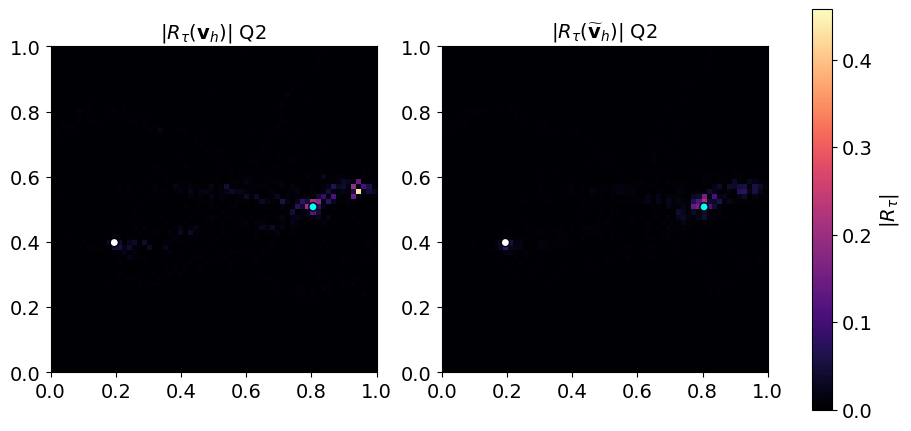

In [3]:
# Deng/Ginting local reconstruction on tensor-product rectangular nodal control volumes.
# Q1: 4 sub-CVs per primal cell.  Q2: 9 sub-CVs per primal cell.
# For Q2 each node-control subcell is bounded by midpoints between neighboring
# Q2 nodes, matching the P2-style centroid/midpoint construction in tensor form.
RUN_DENG_RECONSTRUCTION = True
segment_quad_order = max(3, 2 * CG_ORDER + 1)
_GL, _WL = np.polynomial.legendre.leggauss(segment_quad_order)
_GL = 0.5 * (_GL + 1.0)
_WL = 0.5 * _WL
cell_quad_order = max(3, 2 * CG_ORDER + 1)
_gb, _wb = np.polynomial.legendre.leggauss(cell_quad_order)
_gb = 0.5 * (_gb + 1.0)
_wb = 0.5 * _wb
_QB = np.array([[gx, gy] for gy in _gb for gx in _gb], dtype=float)
_WB = np.array([wx * wy for wy in _wb for wx in _wb], dtype=float)

# Compatibility for the existing Q1 transport cells.
edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)] if CG_ORDER == 1 else []
next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}


def segment_key(a, b, decimals=12):
    ka = tuple(np.round(np.asarray(a, dtype=float), decimals))
    kb = tuple(np.round(np.asarray(b, dtype=float), decimals))
    return tuple(sorted((ka, kb)))


def physical_edge_defs(cell):
    cached = cell.get("physical_edges")
    if cached is not None:
        return cached
    x0, x1 = float(cell["x0"]), float(cell["x1"])
    y0, y1 = float(cell["y0"]), float(cell["y1"])
    edges = [
        ("bottom", np.array([x0, y0], dtype=float), np.array([x1, y0], dtype=float), np.array([0.0, -1.0], dtype=float)),
        ("right",  np.array([x1, y0], dtype=float), np.array([x1, y1], dtype=float), np.array([1.0, 0.0], dtype=float)),
        ("top",    np.array([x0, y1], dtype=float), np.array([x1, y1], dtype=float), np.array([0.0, 1.0], dtype=float)),
        ("left",   np.array([x0, y0], dtype=float), np.array([x0, y1], dtype=float), np.array([-1.0, 0.0], dtype=float)),
    ]
    return [{"side": side, "a": a, "b": b, "normal": n, "key": segment_key(a, b)} for side, a, b, n in edges]


def physical_edge_map(cell):
    cached = cell.get("physical_edge_map")
    if cached is not None:
        return cached
    return {edge["side"]: edge for edge in physical_edge_defs(cell)}


def _node_control_bounds(nodes, idx):
    nodes = np.asarray(nodes, dtype=float)
    idx = int(idx)
    lo = 0.0 if idx == 0 else 0.5 * (nodes[idx - 1] + nodes[idx])
    hi = 1.0 if idx == len(nodes) - 1 else 0.5 * (nodes[idx] + nodes[idx + 1])
    return float(lo), float(hi)


def cv_reference_bounds(cell, gi):
    ix = int(cell["dof_xi_idx"][gi])
    iy = int(cell["dof_eta_idx"][gi])
    xi_l, xi_r = _node_control_bounds(cell["xi_nodes"], ix)
    eta_b, eta_t = _node_control_bounds(cell["eta_nodes"], iy)
    return xi_l, xi_r, eta_b, eta_t


def cv_physical_bounds(cell, gi):
    cached = cell.get("cv_bounds")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l = cell["x0"] + xi_l * cell["hx"]
    x_r = cell["x0"] + xi_r * cell["hx"]
    y_b = cell["y0"] + eta_b * cell["hy"]
    y_t = cell["y0"] + eta_t * cell["hy"]
    return float(x_l), float(x_r), float(y_b), float(y_t)


def cv_polygon(cell, gi):
    cached = cell.get("cv_polygons")
    if cached is not None:
        return cached[int(gi)]
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    return np.array([[x_l, y_b], [x_r, y_b], [x_r, y_t], [x_l, y_t]], dtype=float)


# Compatibility aliases for older debug cells.
def standard_cv_polygon(cell, gi):
    return cv_polygon(cell, gi)


def standard_cv_bounds(cell, gi):
    return cv_physical_bounds(cell, gi)


def cv_internal_segments(cell, gi, tol=1.0e-12):
    cached = cell.get("cv_internal_segments")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    segments = []
    if xi_l > tol:
        segments.append((np.array([x_l, y_b], dtype=float), np.array([x_l, y_t], dtype=float), np.array([-1.0, 0.0], dtype=float)))
    if xi_r < 1.0 - tol:
        segments.append((np.array([x_r, y_b], dtype=float), np.array([x_r, y_t], dtype=float), np.array([1.0, 0.0], dtype=float)))
    if eta_b > tol:
        segments.append((np.array([x_l, y_b], dtype=float), np.array([x_r, y_b], dtype=float), np.array([0.0, -1.0], dtype=float)))
    if eta_t < 1.0 - tol:
        segments.append((np.array([x_l, y_t], dtype=float), np.array([x_r, y_t], dtype=float), np.array([0.0, 1.0], dtype=float)))
    return segments


def cv_physical_edge_segments(cell, gi, tol=1.0e-12):
    cached = cell.get("cv_physical_edge_segments")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    edge_map = physical_edge_map(cell)
    segments = []
    if eta_b <= tol and edge_length([x_l, y_b], [x_r, y_b]) > tol:
        edge = edge_map["bottom"]
        segments.append((np.array([x_l, cell["y0"]], dtype=float), np.array([x_r, cell["y0"]], dtype=float), edge["normal"], edge["key"]))
    if eta_t >= 1.0 - tol and edge_length([x_l, y_t], [x_r, y_t]) > tol:
        edge = edge_map["top"]
        segments.append((np.array([x_l, cell["y1"]], dtype=float), np.array([x_r, cell["y1"]], dtype=float), edge["normal"], edge["key"]))
    if xi_l <= tol and edge_length([x_l, y_b], [x_l, y_t]) > tol:
        edge = edge_map["left"]
        segments.append((np.array([cell["x0"], y_b], dtype=float), np.array([cell["x0"], y_t], dtype=float), edge["normal"], edge["key"]))
    if xi_r >= 1.0 - tol and edge_length([x_r, y_b], [x_r, y_t]) > tol:
        edge = edge_map["right"]
        segments.append((np.array([cell["x1"], y_b], dtype=float), np.array([cell["x1"], y_t], dtype=float), edge["normal"], edge["key"]))
    return segments


def _segment_quadrature_points(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[None, :] + _GL[:, None] * (b - a)[None, :]


def quad_lagrange_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts[:, 0] - cell["x0"]) / cell["hx"]
    eta = (pts[:, 1] - cell["y0"]) / cell["hy"]
    vals, grads = tensor_lagrange_values_grads(cell["pressure_order"], np.column_stack([xi, eta]), cell["hx"], cell["hy"])
    return vals, grads


def segment_flux_basis(cell, a, b, n_out):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n_out = np.asarray(n_out, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return np.zeros(len(cell["dofs"]), dtype=float)
    _, grads = quad_lagrange_values_grads_on_cell(cell, _segment_quadrature_points(a, b))
    normal_grads = np.einsum("qjd,d->qj", grads, n_out)
    return -cell["kappa"] * seg_len * np.einsum("q,qj->j", _WL, normal_grads)


def segment_flux_coeffs(cell, coeffs, a, b, n_out):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n_out = np.asarray(n_out, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    _, grads = quad_lagrange_values_grads_on_cell(cell, _segment_quadrature_points(a, b))
    grad = np.einsum("qjd,j->qd", grads, coeffs)
    return float(-cell["kappa"] * seg_len * np.einsum("q,qd,d->", _WL, grad, n_out))


def grad_from_coeffs(cell, coeffs, x):
    pts = np.asarray(x, dtype=float)
    single = pts.ndim == 1
    pts = pts.reshape(-1, 2)
    _, grads = quad_lagrange_values_grads_on_cell(cell, pts)
    grad = np.einsum("qjd,j->qd", grads, coeffs)
    return grad[0] if single else grad


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    pts = np.asarray(x, dtype=float)
    single = pts.ndim == 1
    pts = pts.reshape(-1, 2)
    n_out = np.asarray(n_out, dtype=float)
    cell = rect["cells"][ci]
    val = cell["kappa"] * grad_from_coeffs(cell, cell["uvals"], pts)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        nb_cell = rect["cells"][nb]
        val_nb = nb_cell["kappa"] * grad_from_coeffs(nb_cell, nb_cell["uvals"], pts)
        val = 0.5 * (val + val_nb)
    dots = val @ n_out
    return float(dots[0]) if single else dots


def integrate_source_over_subrect(ci, x_l, x_r, y_b, y_t):
    return float(source_density_cell[ci] * max(0.0, x_r - x_l) * max(0.0, y_t - y_b))


def cell_volume_terms(cell):
    x_phys = np.column_stack([
        cell["x0"] + _QB[:, 0] * cell["hx"],
        cell["y0"] + _QB[:, 1] * cell["hy"],
    ])
    vals, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
    area = cell["hx"] * cell["hy"]
    f_val = float(source_density_cell[cell["cell_id"]])
    grad_u = np.einsum("qjd,j->qd", grads, cell["uvals"])
    source_phi = area * f_val * np.einsum("q,qi->i", _WB, vals)
    a_term = area * np.einsum("q,qjd,qd->j", _WB, cell["kappa"] * grads, grad_u)
    mass_vec = area * np.einsum("q,qi->i", _WB, vals)
    return source_phi, a_term, mass_vec


def prepare_deng_rect_data():
    pressure_order = int(CG_ORDER)
    nodes_1d = np.linspace(0.0, 1.0, pressure_order + 1)
    dof_xi_idx = np.array([i for j in range(pressure_order + 1) for i in range(pressure_order + 1)], dtype=np.int32)
    dof_eta_idx = np.array([j for j in range(pressure_order + 1) for i in range(pressure_order + 1)], dtype=np.int32)

    cells = []
    edge_to_cells = {}
    vtc = [[] for _ in range(n_nodes)]
    for cid, nodes in enumerate(quad_nodes):
        ix = cid % nx
        iy = cid // nx
        x0, x1 = xmin + ix * hx, xmin + (ix + 1) * hx
        y0, y1 = ymin + iy * hy, ymin + (iy + 1) * hy
        cell = {
            "cell_id": int(cid),
            "dofs": nodes.copy(),
            "vids": nodes.copy(),
            "dof_xy": fem_nodes[nodes].copy(),
            "xy": fem_nodes[nodes].copy(),
            "poly": quad_polys[cid].copy(),
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(hx),
            "hy": float(hy),
            "xi_nodes": nodes_1d.copy(),
            "eta_nodes": nodes_1d.copy(),
            "dof_xi_idx": dof_xi_idx.copy(),
            "dof_eta_idx": dof_eta_idx.copy(),
            "centroid": xc_matrix[cid].copy(),
            "uvals": p_nodes[nodes].copy(),
            "pressure_order": pressure_order,
            "kappa": float(kappa_cell_dg0[cid]),
        }
        cell["physical_edges"] = physical_edge_defs(cell)
        cell["physical_edge_map"] = {edge["side"]: edge for edge in cell["physical_edges"]}
        cells.append(cell)
        for vid in nodes:
            vtc[int(vid)].append(int(cid))
        for edge in cell["physical_edges"]:
            edge_to_cells.setdefault(edge["key"], []).append((int(cid), edge["side"]))

    for cell in cells:
        nd = len(cell["dofs"])
        cell["cv_bounds"] = [cv_physical_bounds(cell, gi) for gi in range(nd)]
        cell["cv_polygons"] = [cv_polygon(cell, gi) for gi in range(nd)]
        cell["cv_internal_segments"] = [cv_internal_segments(cell, gi) for gi in range(nd)]
        cell["cv_physical_edge_segments"] = [cv_physical_edge_segments(cell, gi) for gi in range(nd)]

    return {
        "cells": cells,
        "vertices_xy": fem_nodes.copy(),
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": len(cells),
        "num_vertices": n_nodes,
        "pressure_order": pressure_order,
    }


def solve_deng_singular_system(B, rhs, rcond=1.0e-10):
    U, s, Vt = np.linalg.svd(B, full_matrices=False)
    if s.size == 0 or s[0] == 0.0:
        return np.zeros(B.shape[1], dtype=float), 0, s
    keep = s > rcond * s[0]
    coeffs = Vt[keep, :].T @ ((U[:, keep].T @ rhs) / s[keep])
    return coeffs, int(np.count_nonzero(keep)), s


def deng_postprocess_rect_source(rect):
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}

    for ci in tqdm(range(rect["num_cells"]), desc=f"Deng Q{CG_ORDER} rectangular local solves"):
        cell = rect["cells"][ci]
        nd = len(cell["dofs"])
        B = np.zeros((nd, nd), dtype=float)
        source_t_matrix = np.zeros(nd, dtype=float)
        source_phi_matrix, a_term, mass_vec = cell_volume_terms(cell)
        e_I = np.zeros(nd, dtype=float)
        e_phi = np.zeros(nd, dtype=float)

        for gi in range(nd):
            x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
            source_t_matrix[gi] += integrate_source_over_subrect(ci, x_l, x_r, y_b, y_t)
            for a, b, n_out in cv_internal_segments(cell, gi):
                B[gi, :] += segment_flux_basis(cell, a, b, n_out)

        for edge in physical_edge_defs(cell):
            a = edge["a"]
            b = edge["b"]
            n_out = edge["normal"]
            edge_key = edge["key"]
            seg_len = edge_length(a, b)
            pts = _segment_quadrature_points(a, b)
            phi_edge = quad_lagrange_values_grads_on_cell(cell, pts)[0]
            avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
            e_phi += seg_len * np.einsum("q,q,qi->i", _WL, avg, phi_edge)

        for gi in range(nd):
            for a, b, n_out, edge_key in cv_physical_edge_segments(cell, gi):
                seg_len = edge_length(a, b)
                pts = _segment_quadrature_points(a, b)
                avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
                e_I[gi] += seg_len * float(np.dot(_WL, avg))

        source_t_matrix_raw = source_t_matrix.copy()
        source_defect = float(np.sum(source_phi_matrix) - np.sum(source_t_matrix))
        area = float(np.sum(mass_vec))
        if area > 0.0:
            source_t_matrix += source_defect * mass_vec / area

        source_t = source_t_matrix
        source_phi = source_phi_matrix
        rhs = source_t - source_phi + a_term + e_I - e_phi
        coeffs, local_solve_rank, local_solve_svals = solve_deng_singular_system(B, rhs)
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, cell["uvals"])) - float(np.dot(mass_vec, coeffs))) / area

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "B": B.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_t_matrix_raw": source_t_matrix_raw.copy(),
            "source_compat_defect": source_defect,
            "source_phi_matrix": source_phi_matrix.copy(),
            "rhs": rhs.copy(),
            "local_solve_rank": int(local_solve_rank),
            "local_solve_singular_values": local_solve_svals.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return local_fluxes, coef_glob, p_rec


def averaged_physical_outflux(rect, ci, edge_key, a, b, n_out):
    # Deng's CV balance uses the averaged original K grad(p_h).n on primal-cell
    # edges, with Darcy outflux v.n = -K grad(p_h).n.
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    pts = _segment_quadrature_points(a, b)
    avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
    return float(-seg_len * np.dot(_WL, avg))


def compute_R_tau_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        flux = 0.0
        if use_rec:
            for edge in physical_edge_defs(cell):
                flux += averaged_physical_outflux(rect, ci, edge["key"], edge["a"], edge["b"], edge["normal"])
        else:
            for edge in physical_edge_defs(cell):
                flux += segment_flux_coeffs(cell, cell["uvals"], edge["a"], edge["b"], edge["normal"])
        R[ci] = flux - source_rate_cell[ci]
    return R


def compute_R_xi_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        source_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for a, b, n_out in cv_internal_segments(cell, gi):
                flux_sum += segment_flux_coeffs(cell, coeffs, a, b, n_out)
            for a, b, n_out, edge_key in cv_physical_edge_segments(cell, gi):
                if use_rec:
                    flux_sum += averaged_physical_outflux(rect, ci, edge_key, a, b, n_out)
                else:
                    flux_sum += segment_flux_coeffs(cell, coeffs, a, b, n_out)
            source_sum += local_fluxes[ci]["source_t"][gi]
        R[vid] = flux_sum - source_sum
    return R


def boundary_vertex_mask_rect(rect, tol=1.0e-12):
    xy = rect["vertices_xy"]
    return (
        np.isclose(xy[:, 0], xmin, atol=tol)
        | np.isclose(xy[:, 0], xmax, atol=tol)
        | np.isclose(xy[:, 1], ymin, atol=tol)
        | np.isclose(xy[:, 1], ymax, atol=tol)
    )


def q_nlr_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    out = np.zeros((len(pts), 2), dtype=float)
    for ci in np.unique(cids):
        mask = cids == ci
        cell = rect["cells"][int(ci)]
        coeffs = local_fluxes[int(ci)]["coeffs"]
        out[mask] = -cell["kappa"] * grad_from_coeffs(cell, coeffs, pts[mask])
    return out


def q_nlr_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids, _, _ = locate_rect_cells(pts)
    return q_nlr_on_rect_cell_numpy(pts, cids)

start = time.time()
rect = prepare_deng_rect_data()
if RUN_DENG_RECONSTRUCTION:
    local_fluxes, coef_glob, p_rec = deng_postprocess_rect_source(rect)
else:
    local_fluxes, coef_glob, p_rec = {}, {}, np.full(rect["num_vertices"], np.nan)
print(f"Deng/NLR Q{CG_ORDER} reconstruction time: {time.time() - start:.2f}s")
p_nlr_nodes = p_rec.copy()

R_tau_cg = compute_R_tau_rect(rect, local_fluxes, use_rec=False)
R_tau_nlr = compute_R_tau_rect(rect, local_fluxes, use_rec=True)
R_xi_cg = compute_R_xi_rect(rect, local_fluxes, use_rec=False)
R_xi_nlr = compute_R_xi_rect(rect, local_fluxes, use_rec=True)
boundary_vids = boundary_vertex_mask_rect(rect)
source_vertex_ids = np.unique(np.concatenate([quad_nodes[int(cid)] for cid in source_cell_ids])).astype(np.int64)
interior_vids = ~boundary_vids
interior_vertex_ids = np.flatnonzero(interior_vids)
boundary_vertex_ids = np.flatnonzero(boundary_vids)

print(f"Deng/NLR Q{CG_ORDER} local conservation on primal cells R_tau:")
print("  CG :", residual_stats(R_tau_cg))
print("  NLR:", residual_stats(R_tau_nlr))
print(f"Deng/NLR Q{CG_ORDER} local conservation on nodal dual CVs R_xi:")
print("  CG interior :", residual_stats(R_xi_cg, np.flatnonzero(interior_vids)))
print("  NLR interior:", residual_stats(R_xi_nlr, np.flatnonzero(interior_vids)))
print("  CG source nodes :", residual_stats(R_xi_cg, source_vertex_ids))
print("  NLR source nodes:", residual_stats(R_xi_nlr, source_vertex_ids))
if local_fluxes:
    ranks = np.array([lf.get("local_solve_rank", np.nan) for lf in local_fluxes.values()], dtype=float)
    compat = np.array([lf.get("source_compat_defect", 0.0) for lf in local_fluxes.values()], dtype=float)
    print(f"  local solve rank range: [{np.nanmin(ranks):.0f}, {np.nanmax(ranks):.0f}] of {(CG_ORDER + 1) ** 2}")
    print(f"  source compatibility max|defect|={np.max(np.abs(compat)):.3e}")
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    vmax = max(np.max(np.abs(R_tau_cg)), np.max(np.abs(R_tau_nlr)), 1.0e-14)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), constrained_layout=True)
    for ax, data, title in zip(axes, [R_tau_cg, R_tau_nlr], [rf"$|R_\tau(\mathbf{{v}}_h)|$ Q{CG_ORDER}", rf"$|R_\tau(\widetilde{{\mathbf{{v}}}}_h)|$ Q{CG_ORDER}"]):
        pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(np.abs(data)), cmap="magma", shading="flat", vmin=0.0, vmax=vmax)
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "cyan"], s=35, edgecolors="k", zorder=5)
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    cbar = fig.colorbar(pcm, ax=axes, fraction=0.046, pad=0.04)
    cbar.set_label(r"$|R_\tau|$")
    plt.show()


In [4]:
# Vertex-centred CVFEM pressure solve on the active Deng Qk nodal dual control volumes.
# CG_ORDER=1 gives the old Q1 nodal dual mesh; CG_ORDER=2 gives the Q2/P2-style
# dual mesh built from midpoint-bounded sub-CVs around the Q2 nodes.
RUN_CVFEM_SOLVE = bool(globals().get("RUN_CVFEM_SOLVE", True))
CVFEM_ACTIVE = RUN_CVFEM_SOLVE


def assemble_cvfem_pressure_system():
    A_cv = lil_matrix((n_nodes, n_nodes), dtype=float)
    b_cv = np.zeros(n_nodes, dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        nodes = cell["vids"]
        for gi, vid in enumerate(nodes):
            row = int(vid)
            b_cv[row] += local_fluxes[ci]["source_t"][gi]
            for a, bseg, n_out in cv_internal_segments(cell, gi):
                basis = segment_flux_basis(cell, a, bseg, n_out)
                for lid, gid in enumerate(nodes):
                    A_cv[row, int(gid)] += basis[lid]
    return A_cv, b_cv


if CVFEM_ACTIVE:
    A_cvfem, b_cvfem = assemble_cvfem_pressure_system()
    A_cvfem = A_cvfem.tolil()
    b_cvfem -= A_cvfem[:, boundary_nodes].dot(p_dirichlet[boundary_nodes])
    for idx in np.flatnonzero(boundary_nodes):
        A_cvfem.rows[idx] = [int(idx)]
        A_cvfem.data[idx] = [1.0]
    for idx in np.flatnonzero(boundary_nodes):
        A_cvfem[:, idx] = 0.0
        A_cvfem[idx, idx] = 1.0
        b_cvfem[idx] = p_dirichlet[idx]
    p_cvfem_nodes = np.asarray(spsolve(A_cvfem.tocsr(), b_cvfem), dtype=float)
else:
    A_cvfem = None
    b_cvfem = None
    p_cvfem_nodes = np.full(n_nodes, np.nan, dtype=float)


def p_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, xi, eta = locate_rect_cells(pts)
    phi = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[0]
    return np.einsum("ni,ni->n", phi, p_cvfem_nodes[quad_nodes[cid]])


def grad_p_cvfem_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    grads = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[1]
    return np.einsum("nld,nl->nd", grads, p_cvfem_nodes[quad_nodes[cids]])


def grad_p_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return grad_p_cvfem_on_rect_cell_numpy(pts, cid)


def q_cvfem_on_rect_cell_numpy(points, cell_ids):
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    return -kappa_cell_dg0[cids, None] * grad_p_cvfem_on_rect_cell_numpy(points, cids)


def q_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_cvfem_on_rect_cell_numpy(pts, cid)


def compute_R_tau_coeffs_rect(rect, local_fluxes_like):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        coeffs = local_fluxes_like[ci]["coeffs"]
        flux = 0.0
        for edge in physical_edge_defs(cell):
            flux += segment_flux_coeffs(cell, coeffs, edge["a"], edge["b"], edge["normal"])
        R[ci] = flux - source_rate_cell[ci]
    return R


if CVFEM_ACTIVE:
    p_matrix_cvfem = p_cvfem_numpy(xc_matrix)
    grad_cell_cvfem = grad_p_cvfem_numpy(xc_matrix)
    q_cell_cvfem = -kappa_cell_dg0[:, None] * grad_cell_cvfem
    local_fluxes_cvfem = {
        ci: {
            "coeffs": p_cvfem_nodes[cell["vids"]].copy(),
            "source_t": local_fluxes[ci]["source_t"].copy(),
        }
        for ci, cell in enumerate(rect["cells"])
    }
    R_tau_cvfem = compute_R_tau_coeffs_rect(rect, local_fluxes_cvfem)
    R_xi_cvfem = compute_R_xi_rect(rect, local_fluxes_cvfem, use_rec=True)

    print(f"CVFEM Q{CG_ORDER} pressure solve on nodal dual control volumes")
    print(f"  p range: [{p_cvfem_nodes.min():+.6e}, {p_cvfem_nodes.max():+.6e}]")
    print(f"  mean|p_CVFEM-p_CG|={np.mean(np.abs(p_matrix_cvfem - p_matrix_cg)):.3e}, max|p_CVFEM-p_CG|={np.max(np.abs(p_matrix_cvfem - p_matrix_cg)):.3e}")
    if MRST_REFERENCE_AVAILABLE:
        p_matrix_diff_cvfem_mrst = p_matrix_cvfem - p_matrix_mrst_export
        print(f"  matched MRST pressure mean|e|={np.mean(np.abs(p_matrix_diff_cvfem_mrst)):.3e}, max|e|={np.max(np.abs(p_matrix_diff_cvfem_mrst)):.3e}")
    print("  CVFEM conservation residuals")
    print("    R_tau CVFEM       :", residual_stats(R_tau_cvfem))
    print("    R_xi CVFEM int    :", residual_stats(R_xi_cvfem, interior_vertex_ids))
    print("    R_xi CVFEM source :", residual_stats(R_xi_cvfem, source_vertex_ids))
else:
    p_matrix_cvfem = np.full(ncell, np.nan, dtype=float)
    grad_cell_cvfem = np.full((ncell, 2), np.nan, dtype=float)
    q_cell_cvfem = np.full((ncell, 2), np.nan, dtype=float)
    local_fluxes_cvfem = {}
    R_tau_cvfem = np.full(ncell, np.nan, dtype=float)
    R_xi_cvfem = np.full(n_nodes, np.nan, dtype=float)
    print("CVFEM pressure solve skipped by RUN_CVFEM_SOLVE=False.")


CVFEM Q2 pressure solve on nodal dual control volumes
  p range: [-7.017336e-01, +2.956714e-01]
  mean|p_CVFEM-p_CG|=2.409e-04, max|p_CVFEM-p_CG|=7.685e-03
  matched MRST pressure mean|e|=5.197e-03, max|e|=1.519e-01
  CVFEM conservation residuals
    R_tau CVFEM       : n=4096 mean|R|=2.776224e-03 median|R|=3.075446e-04 rmse=1.681389e-02 max|R|=5.282796e-01 sum(R)=-7.932539e-03
    R_xi CVFEM int    : n=16129 mean|R|=4.543227e-16 median|R|=2.428613e-17 rmse=2.573385e-15 max|R|=1.590394e-13 sum(R)=+5.975528e-13
    R_xi CVFEM source : n=18 mean|R|=1.435580e-15 median|R|=1.165734e-15 rmse=1.937019e-15 max|R|=4.107825e-15 sum(R)=+2.720046e-15


In [5]:
# Optional CG+PINN gradient reconstruction.
# For the source-sink problem the divergence target is singular.  The default
# div-loss therefore excludes the two source/sink cells and enforces div(v)=0
# only away from them; the source balance is assessed by the finite-volume
# diagnostics rather than a pointwise neural divergence at the delta cells.
# Set this to False to skip the PINN branch entirely.  When disabled,
# downstream diagnostics/plots use only CG, NLR, and optional MRST.
ENABLE_PINN_RECONSTRUCTION = False
RUN_PINN_TRAINING = True
PINN_EPOCHS = 3000
PINN_LR = 2.0e-3
PINN_HIDDEN_DIM = 64
PINN_DEPTH = 5
BATCH_DATA = 4096
BATCH_DIV = 4096
W_DATA = 10.0
W_DIV = 1.0
W_SLOPE = 1.0e-4
PINN_EXCLUDE_SOURCE_CELLS_FROM_DIV = True
pinn_history = {"epoch": [], "loss": [], "data": [], "div": [], "slope": []}
pinn_training_time = 0.0
PINN_ACTIVE = bool(ENABLE_PINN_RECONSTRUCTION and RUN_PINN_TRAINING and TORCH_AVAILABLE)


def harmonic_mean(a, b, eps=1.0e-300):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return 2.0 * a * b / (a + b + eps)

_data_pts_np = xc_matrix.copy()
_data_grad_cg_np = grad_p_cg_numpy(_data_pts_np)
_grad_mean_np = np.mean(_data_grad_cg_np, axis=0)
_grad_std_np = np.std(_data_grad_cg_np, axis=0)
_grad_std_np = np.where(_grad_std_np > 1.0e-12, _grad_std_np, 1.0)
_data_grad_norm_np = (_data_grad_cg_np - _grad_mean_np[None, :]) / _grad_std_np[None, :]

_div_cell_mask = np.ones(ncell, dtype=bool)
if PINN_EXCLUDE_SOURCE_CELLS_FROM_DIV:
    _div_cell_mask[source_cell_ids] = False
_div_pts_np = xc_matrix[_div_cell_mask]
_div_target_np = source_density_cell[_div_cell_mask]
_div_kappa_np = kappa_cell_dg0[_div_cell_mask]


def logk_feature_numpy(points):
    return np.log10(np.maximum(kappa_numpy(points), 1.0e-300))

_logk_data_np = logk_feature_numpy(_data_pts_np)
_logk_mean_np = float(np.mean(_logk_data_np))
_logk_std_np = float(np.std(_logk_data_np))
if not np.isfinite(_logk_std_np) or _logk_std_np <= 1.0e-12:
    _logk_std_np = 1.0


def build_gradnet_features(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    logk_norm = (logk_feature_numpy(pts) - _logk_mean_np) / _logk_std_np
    return np.column_stack([pts, logk_norm])

_data_feat_np = build_gradnet_features(_data_pts_np)
_div_feat_np = build_gradnet_features(_div_pts_np)
print(f"PINN gradient-data samples: Q{CG_ORDER} cell centers ({len(_data_pts_np)} samples)")
print(f"PINN div samples: {len(_div_pts_np)} cells; source cells excluded={PINN_EXCLUDE_SOURCE_CELLS_FROM_DIV}")
print(f"Gradient normalization: mean={_grad_mean_np}, std={_grad_std_np}")

if PINN_ACTIVE:
    class AdaptiveTanh(nn.Module):
        def __init__(self, n=5.0):
            super().__init__()
            self.a = nn.Parameter(torch.tensor(1.0 / n, dtype=torch.float32))

        def forward(self, x):
            return torch.tanh(self.a * x)

    class GradNet(nn.Module):
        def __init__(self, in_dim=3, out_dim=2, hidden_dim=PINN_HIDDEN_DIM, num_hidden_layers=PINN_DEPTH, n=5.0):
            super().__init__()
            layers = []
            last = in_dim
            for _ in range(num_hidden_layers):
                layer = nn.Linear(last, hidden_dim)
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layers += [layer, AdaptiveTanh(n=n)]
                last = hidden_dim
            out = nn.Linear(last, out_dim)
            nn.init.xavier_uniform_(out.weight)
            nn.init.zeros_(out.bias)
            layers.append(out)
            self.net = nn.Sequential(*layers)
            self.register_buffer("center", torch.tensor([0.5 * physdim[0], 0.5 * physdim[1], 0.0], dtype=torch.float32))
            self.register_buffer("scale", torch.tensor([max(physdim), max(physdim), 1.0], dtype=torch.float32))

        def forward(self, x):
            z = (x - self.center) / self.scale
            return self.net(z)

        def slope_recovery_term(self):
            slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
            if not slopes:
                return torch.tensor(0.0, dtype=torch.float32, device=self.center.device)
            return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

    def to_torch(x, requires_grad=False):
        t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
        if requires_grad:
            t = t.clone().detach().requires_grad_(True)
        return t

    def unscale_grad_torch(g_norm):
        return g_norm * grad_std_t + grad_mean_t

    def div_of_flux_from_grad(net, x, kappa_values):
        x = x.clone().detach().requires_grad_(True)
        kappa_values = kappa_values.reshape(-1, 1)
        g = unscale_grad_torch(net(x))
        q = -kappa_values * g
        dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True, retain_graph=True)[0][:, 0]
        dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True, retain_graph=True)[0][:, 1]
        return dq0 + dq1

    def mse(x):
        return torch.mean(x ** 2)

    grad_net = GradNet().to(device)
    grad_mean_t = to_torch(_grad_mean_np)
    grad_std_t = to_torch(_grad_std_np)
    X_data_t = to_torch(_data_feat_np)
    G_data_t = to_torch(_data_grad_norm_np)
    X_div_t = to_torch(_div_feat_np)
    F_div_t = to_torch(_div_target_np)
    K_div_t = to_torch(_div_kappa_np)

    opt = torch.optim.Adam(grad_net.parameters(), lr=PINN_LR)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.45 * PINN_EPOCHS), int(0.75 * PINN_EPOCHS)], gamma=0.35)

    def compute_reconstruction_loss():
        n_data = X_data_t.shape[0]
        idx_d = torch.randint(0, n_data, (min(BATCH_DATA, n_data),), device=device)
        loss_data = mse(grad_net(X_data_t[idx_d]) - G_data_t[idx_d])

        n_div = X_div_t.shape[0]
        idx_v = torch.randint(0, n_div, (min(BATCH_DIV, n_div),), device=device)
        loss_div = mse(div_of_flux_from_grad(grad_net, X_div_t[idx_v], K_div_t[idx_v]) - F_div_t[idx_v])
        loss_slope = grad_net.slope_recovery_term()
        total = W_DATA * loss_data + W_DIV * loss_div + W_SLOPE * loss_slope
        return total, {"data": loss_data.detach(), "div": loss_div.detach(), "slope": loss_slope.detach()}

    if RUN_PINN_TRAINING:
        best_state = None
        best_loss = float("inf")
        best_start = int(0.8 * PINN_EPOCHS)
        t0 = time.perf_counter()
        for epoch in tqdm(range(1, PINN_EPOCHS + 1), desc=f"SPE10 Q{CG_ORDER} gradient PINN reconstruction"):
            opt.zero_grad(set_to_none=True)
            loss, parts = compute_reconstruction_loss()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(grad_net.parameters(), max_norm=1.0)
            opt.step()
            scheduler.step()
            row = {"epoch": epoch, "loss": float(loss.detach().cpu())}
            row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
            if epoch >= best_start and row["loss"] < best_loss:
                best_loss = row["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in grad_net.state_dict().items()}
            if epoch == 1 or epoch == PINN_EPOCHS or epoch % max(1, PINN_EPOCHS // 5) == 0:
                for key in pinn_history:
                    if key == "epoch":
                        pinn_history[key].append(epoch)
                    else:
                        pinn_history[key].append(row[key])
        pinn_training_time = time.perf_counter() - t0
        if best_state is not None:
            grad_net.load_state_dict(best_state)
            print("restored best gradient-PINN reconstruction loss:", best_loss)

    @torch.no_grad()
    def grad_rec_numpy(points, batch=200000):
        grad_net.eval()
        pts = np.asarray(points, dtype=float).reshape(-1, 2)
        feat = build_gradnet_features(pts).astype(np.float32)
        out = []
        for i0 in range(0, len(feat), batch):
            xb = torch.as_tensor(feat[i0:i0 + batch], dtype=torch.float32, device=device)
            gb = unscale_grad_torch(grad_net(xb))
            out.append(gb.cpu().numpy().astype(float))
        return np.vstack(out) if out else np.zeros((0, 2), dtype=float)
else:
    grad_net = None

    def grad_rec_numpy(points, batch=200000):
        return grad_p_cg_numpy(points)


def q_rec_numpy(points, batch=200000):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return -kappa_numpy(pts)[:, None] * grad_rec_numpy(pts, batch=batch)

q_net = grad_net
probe = np.random.rand(10000, 2) * physdim[None, :]
gcg_probe = grad_p_cg_numpy(probe)
grec_probe = grad_rec_numpy(probe)
qcg_probe = q_cg_numpy(probe)
qrec_probe = q_rec_numpy(probe)
print(f"PINN reconstruction enabled: {ENABLE_PINN_RECONSTRUCTION}")
print(f"Torch available for PINN training: {TORCH_AVAILABLE}")
print(f"PINN active in downstream diagnostics: {PINN_ACTIVE}")
if PINN_ACTIVE:
    print(f"PINN reconstruction training time: {pinn_training_time:.3f} s")
    print(f"PINN gradient |g_theta-grad p_h|: mean={np.mean(np.linalg.norm(grec_probe - gcg_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(grec_probe - gcg_probe, axis=1)):.3e}")
    print(f"PINN flux |v_theta-v_h| with cell kappa: mean={np.mean(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}")
else:
    print("PINN skipped: q_rec_numpy falls back to the CG gradient for compatibility, and the PINN method is omitted downstream.")
if pinn_history["epoch"]:
    print("PINN reconstruction loss history:")
    for e, loss, data, div, slope in zip(pinn_history["epoch"], pinn_history["loss"], pinn_history["data"], pinn_history["div"], pinn_history["slope"]):
        print(f"  epoch={e:5d} loss={loss:.3e} data={data:.3e} div={div:.3e} slope={slope:.3e}")


PINN gradient-data samples: Q2 cell centers (4096 samples)
PINN div samples: 4094 cells; source cells excluded=True
Gradient normalization: mean=[ 0.00000000e+00 -1.19160383e-16], std=[0.81951051 0.96123939]
PINN reconstruction enabled: False
Torch available for PINN training: True
PINN active in downstream diagnostics: False
PINN skipped: q_rec_numpy falls back to the CG gradient for compatibility, and the PINN method is omitted downstream.


In [21]:
# Rectangular-grid face flux diagnostic only.  The Deng transport below uses the nodal dual mesh C_z.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor
inlet_s = np.full(owner.shape, BOUNDARY_INFLOW_S, dtype=float)


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def _face_quadrature(n_quad=2):
    if n_quad == 1:
        return np.array([0.5], dtype=float), np.array([1.0], dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(n_quad)
    return 0.5 * (xi + 1.0), 0.5 * wi


def face_global_flux_from_cell_velocity(velocity_on_cell_fn, n_quad=2, average_internal=True):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = np.zeros_like(pts)
        if np.any(internal):
            q1v = velocity_on_cell_fn(pts[internal], cell1[internal])
            if average_internal:
                q2v = velocity_on_cell_fn(pts[internal], cell2[internal])
                vel[internal] = 0.5 * (q1v + q2v)
            else:
                vel[internal] = q1v
        if np.any(~internal):
            vel[~internal] = velocity_on_cell_fn(pts[~internal], owner_cell[~internal])
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


def face_global_flux_from_gradient_harmonic(gradient_fn, n_quad=2):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    k_face = np.empty(face_len.size, dtype=float)
    k_face[internal] = harmonic_mean(kappa_cell_dg0[cell1[internal]], kappa_cell_dg0[cell2[internal]])
    k_face[~internal] = kappa_cell_dg0[owner_cell[~internal]]
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        grad = gradient_fn(pts)
        vel = -k_face[:, None] * grad
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux

face_flux_cg_global = face_global_flux_from_cell_velocity(q_cg_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_nlr_global = face_global_flux_from_cell_velocity(q_nlr_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_cvfem_global = face_global_flux_from_cell_velocity(q_cvfem_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_pinn_global = None

Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_NLR = global_face_flux_to_fout(face_flux_nlr_global)
Fout_CVFEM = global_face_flux_to_fout(face_flux_cvfem_global)
transport_fluxes = {"CG": Fout_CG, "NLR": Fout_NLR, "CVFEM": Fout_CVFEM}
face_flux_by_method = {"CG": face_flux_cg_global, "NLR": face_flux_nlr_global, "CVFEM": face_flux_cvfem_global}
if PINN_ACTIVE:
    face_flux_pinn_global = face_global_flux_from_gradient_harmonic(grad_rec_numpy, n_quad=2)
    Fout_PINN = global_face_flux_to_fout(face_flux_pinn_global)
    transport_fluxes["PINN"] = Fout_PINN
    face_flux_by_method["PINN"] = face_flux_pinn_global
else:
    print("PINN rectangular-face diagnostic skipped.")
if MRST_REFERENCE_AVAILABLE:
    Fout_MRST = global_face_flux_to_fout(face_flux_mrst_export)
    transport_fluxes["MRST"] = Fout_MRST
    face_flux_by_method["MRST"] = face_flux_mrst_export


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual - source_rate_cell

print("Rectangular-cell diagnostic only (not the Deng transport CV): sum outward face flux minus cell source int_K f:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<5} {residual_stats(r)}")
if MRST_REFERENCE_AVAILABLE:
    print("Face-flux comparison relative to matched MRST/TPFA:")
    for name, Fout in transport_fluxes.items():
        err = Fout - Fout_MRST
        print(f"  {name:<5} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("Boundary single-phase flux audit, signed outward sums:")
_boundary_masks = {
    "left": is_boundary_face & np.isclose(face_centroid[:, 0], xmin, atol=1.0e-12),
    "right": is_boundary_face & np.isclose(face_centroid[:, 0], xmax, atol=1.0e-12),
    "bottom": is_boundary_face & np.isclose(face_centroid[:, 1], ymin, atol=1.0e-12),
    "top": is_boundary_face & np.isclose(face_centroid[:, 1], ymax, atol=1.0e-12),
}
for side, mask in _boundary_masks.items():
    row = [f"  {side:<6}"]
    for name, flux in face_flux_by_method.items():
        row.append(f"{name} sum={np.sum(flux[mask]):+.3e}")
    print("; ".join(row))


PINN rectangular-face diagnostic skipped.
Rectangular-cell diagnostic only (not the Deng transport CV): sum outward face flux minus cell source int_K f:
  CG    n=4096 mean|R|=1.599767e-03 median|R|=2.241433e-04 rmse=1.056713e-02 max|R|=4.573976e-01 sum(R)=+6.465769e-05
  NLR   n=4096 mean|R|=2.256088e-03 median|R|=2.707236e-04 rmse=1.757832e-02 max|R|=7.660758e-01 sum(R)=+7.377102e-05
  CVFEM n=4096 mean|R|=1.799733e-03 median|R|=2.276650e-04 rmse=1.383553e-02 max|R|=6.123175e-01 sum(R)=+7.549008e-05
  MRST  n=4096 mean|R|=3.916778e-16 median|R|=2.233456e-17 rmse=1.785584e-15 max|R|=4.947431e-14 sum(R)=+1.727400e-13
Face-flux comparison relative to matched MRST/TPFA:
  CG    mean|F-F_FV|=1.468e-03, rmse=7.347e-03, max|F-F_FV|=2.141e-01
  NLR   mean|F-F_FV|=1.463e-03, rmse=8.392e-03, max|F-F_FV|=3.020e-01
  CVFEM mean|F-F_FV|=1.491e-03, rmse=7.839e-03, max|F-F_FV|=2.635e-01
  MRST  mean|F-F_FV|=0.000e+00, rmse=0.000e+00, max|F-F_FV|=0.000e+00
Boundary single-phase flux audit, signed ou

MRST transport is not included on this Deng nodal dual mesh unless a matching MRST dual export is loaded in the plotting cell.
Aggregated Deng P2 transport interfaces: 33540 from 49920 subfaces
Matched MRST dual-volume interfaces: 33540 / 33540
Aggregated P2 dual-volume flux error, int_e (v_w-v_FV).n ds:
  method        total L2      relL2      mean|e|        RMSE       max|e|
  CG       2.281871e-01  3.222e-02   2.2468e-04  1.2460e-03  5.3060e-02
  NLR      2.064539e-01  2.915e-02   2.0439e-04  1.1273e-03  7.0325e-02
  CVFEM    1.919941e-01  2.711e-02   2.0546e-04  1.0484e-03  6.2776e-02


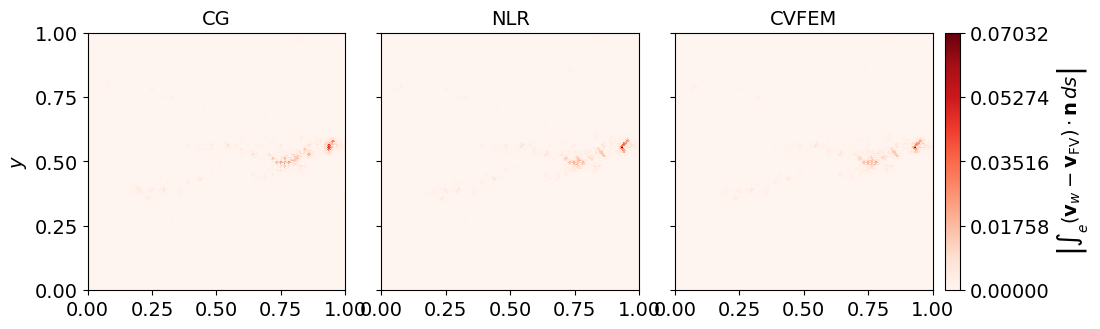

Deng Q2 nodal-dual single-phase balance, sum outward dual-face flux minus source:
  CG    all=n=16641 mean|R|=3.652371e-04 median|R|=3.780455e-05 rmse=2.136792e-03 max|R|=9.383068e-02 sum(R)=+6.465769e-05
        interior=n=16129 mean|R|=3.725657e-04 median|R|=3.945450e-05 rmse=2.167588e-03 max|R|=9.383068e-02 sum(R)=-8.910790e-06
  NLR   all=n=16641 mean|R|=3.274337e-06 median|R|=3.968180e-17 rmse=8.555675e-05 max|R|=7.465582e-03 sum(R)=+7.377102e-05
        interior=n=16129 mean|R|=6.454008e-16 median|R|=3.523657e-17 rmse=2.954601e-15 max|R|=1.253719e-13 sum(R)=-2.769763e-13
  CVFEM all=n=16641 mean|R|=3.374691e-06 median|R|=2.732189e-17 rmse=8.643046e-05 max|R|=7.463762e-03 sum(R)=+7.549008e-05
        interior=n=16129 mean|R|=4.544099e-16 median|R|=2.428613e-17 rmse=2.573385e-15 max|R|=1.590312e-13 sum(R)=+5.979266e-13


In [22]:
# Q2 Deng dual-volume flux assembly + MRST transport-flux error diagnostic.
# This is the transport mesh for which the Deng/NLR reconstruction is locally conservative.
from matplotlib.colors import Normalize
RUN_DUAL_TRANSPORT = bool(globals().get("RUN_DUAL_TRANSPORT", True))
dual_nx_nodes = nodes_per_axis_x
dual_ny_nodes = nodes_per_axis_y
dual_shape = (dual_ny_nodes, dual_nx_nodes)


def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def segment_flux_velocity_fn(velocity_fn, a, bpt, n_out):
    a = np.asarray(a, dtype=float)
    bpt = np.asarray(bpt, dtype=float)
    seg_len = edge_length(a, bpt)
    flux = 0.0
    for t, w in zip(_GL, _WL):
        x = a + t * (bpt - a)
        vel = velocity_fn(x[None, :])[0]
        flux += w * float(np.dot(vel, n_out)) * seg_len
    return float(flux)


def _local_index_map(cell):
    return {
        (int(cell["dof_xi_idx"][gi]), int(cell["dof_eta_idx"][gi])): int(gi)
        for gi in range(len(cell["vids"]))
    }


def _neighbor_gi_from_normal(cell, gi, n_out):
    ix = int(cell["dof_xi_idx"][gi])
    iy = int(cell["dof_eta_idx"][gi])
    if n_out[0] < -0.5:
        key = (ix - 1, iy)
    elif n_out[0] > 0.5:
        key = (ix + 1, iy)
    elif n_out[1] < -0.5:
        key = (ix, iy - 1)
    elif n_out[1] > 0.5:
        key = (ix, iy + 1)
    else:
        raise ValueError("Axis-aligned Qk dual segment normal expected.")
    return _local_index_map(cell)[key]


dual_pv = np.zeros(n_nodes, dtype=float)
dual_source_rate = np.zeros(n_nodes, dtype=float)
for ci, cell in enumerate(rect["cells"]):
    for gi, vid in enumerate(cell["vids"]):
        x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
        subarea = max(0.0, x_r - x_l) * max(0.0, y_t - y_b)
        dual_pv[int(vid)] += phi_matrix * subarea
        dual_source_rate[int(vid)] += local_fluxes[ci]["source_t"][gi]

dual_owner = []
dual_neigh = []
dual_face_p1 = []
dual_face_p2 = []
dual_face_centroid = []
dual_flux_by_method = {"CG": [], "NLR": []}
if CVFEM_ACTIVE:
    dual_flux_by_method["CVFEM"] = []
if PINN_ACTIVE:
    dual_flux_by_method["PINN"] = []

for ci, cell in enumerate(rect["cells"]):
    coeffs_by_method = {"CG": cell["uvals"], "NLR": local_fluxes[ci]["coeffs"]}
    if CVFEM_ACTIVE:
        coeffs_by_method["CVFEM"] = p_cvfem_nodes[cell["vids"]]

    for gi, vid in enumerate(cell["vids"]):
        owner_vid = int(vid)
        for a, bseg, n_out in cv_internal_segments(cell, gi):
            gj = _neighbor_gi_from_normal(cell, gi, n_out)
            neigh_vid = int(cell["vids"][gj])
            if owner_vid > neigh_vid:
                continue
            dual_owner.append(owner_vid)
            dual_neigh.append(neigh_vid)
            dual_face_p1.append(np.asarray(a, dtype=float).copy())
            dual_face_p2.append(np.asarray(bseg, dtype=float).copy())
            dual_face_centroid.append(0.5 * (np.asarray(a, dtype=float) + np.asarray(bseg, dtype=float)))
            for name, coeffs in coeffs_by_method.items():
                dual_flux_by_method[name].append(segment_flux_coeffs(cell, coeffs, a, bseg, n_out))
            if PINN_ACTIVE:
                dual_flux_by_method["PINN"].append(segment_flux_velocity_fn(q_rec_numpy, a, bseg, n_out))

        for a, bseg, n_out, edge_key in cv_physical_edge_segments(cell, gi):
            if len(rect["edge_to_cells"].get(edge_key, [])) != 1:
                continue
            dual_owner.append(owner_vid)
            dual_neigh.append(-1)
            dual_face_p1.append(np.asarray(a, dtype=float).copy())
            dual_face_p2.append(np.asarray(bseg, dtype=float).copy())
            dual_face_centroid.append(0.5 * (np.asarray(a, dtype=float) + np.asarray(bseg, dtype=float)))
            for name, coeffs in coeffs_by_method.items():
                dual_flux_by_method[name].append(segment_flux_coeffs(cell, coeffs, a, bseg, n_out))
            if PINN_ACTIVE:
                dual_flux_by_method["PINN"].append(segment_flux_velocity_fn(q_rec_numpy, a, bseg, n_out))

dual_owner = np.asarray(dual_owner, dtype=np.int64)
dual_neigh = np.asarray(dual_neigh, dtype=np.int64)
dual_face_p1 = np.asarray(dual_face_p1, dtype=float).reshape(-1, 2)
dual_face_p2 = np.asarray(dual_face_p2, dtype=float).reshape(-1, 2)
dual_face_centroid = np.asarray(dual_face_centroid, dtype=float).reshape(-1, 2)
dual_has_neighbor = dual_neigh >= 0
dual_is_boundary = ~dual_has_neighbor
dual_flux_by_method = {name: np.asarray(vals, dtype=float) for name, vals in dual_flux_by_method.items()}
if "MRST" in transport_fluxes:
    print("MRST transport is not included on this Deng nodal dual mesh unless a matching MRST dual export is loaded in the plotting cell.")

# Matched MRST comparison for the actual dual-volume fluxes used below.
# The P2 Deng CV boundary is stored as element-local subfaces.  MRST exports one
# flux per dual-volume interface, so aggregate subfaces with the same owner/neigh
# pair before subtracting the FV flux.
active_dual_face_flux_error = {}
active_dual_face_flux_error_l2 = {}
mrst_dual_flux_on_transport_faces = None
_transport_face_len = np.linalg.norm(dual_face_p2 - dual_face_p1, axis=1)
def _dual_boundary_side(pt, tol=1.0e-12):
    x, y = float(pt[0]), float(pt[1])
    if abs(x - xmin) <= tol:
        return "L"
    if abs(x - xmax) <= tol:
        return "R"
    if abs(y - ymin) <= tol:
        return "B"
    if abs(y - ymax) <= tol:
        return "T"
    return "?"

def _dual_interface_key(owner, neigh, centroid):
    owner = int(owner)
    neigh = int(neigh)
    if neigh >= 0:
        return (owner, neigh)
    return (owner, -1, _dual_boundary_side(centroid))

_agg_index = {}
_agg_owner = []
_agg_neigh = []
_agg_len = []
_agg_centroid_num = []
_agg_flux_by_method = {name: [] for name in dual_flux_by_method}
for _i, (_owner, _neigh) in enumerate(zip(dual_owner, dual_neigh)):
    _key = _dual_interface_key(_owner, _neigh, dual_face_centroid[_i])
    _j = _agg_index.get(_key)
    if _j is None:
        _j = len(_agg_owner)
        _agg_index[_key] = _j
        _agg_owner.append(_key[0])
        _agg_neigh.append(_key[1])
        _agg_len.append(0.0)
        _agg_centroid_num.append(np.zeros(2, dtype=float))
        for _name in dual_flux_by_method:
            _agg_flux_by_method[_name].append(0.0)
    _seg_len = float(_transport_face_len[_i])
    _agg_len[_j] += _seg_len
    _agg_centroid_num[_j] += _seg_len * dual_face_centroid[_i]
    for _name, _Fout in dual_flux_by_method.items():
        _agg_flux_by_method[_name][_j] += float(_Fout[_i])

_agg_keys = list(_agg_index.keys())
_agg_owner = np.asarray(_agg_owner, dtype=np.int64)
_agg_neigh = np.asarray(_agg_neigh, dtype=np.int64)
_agg_len = np.asarray(_agg_len, dtype=float)
_agg_centroid = np.vstack(_agg_centroid_num) / np.maximum(_agg_len[:, None], 1.0e-300)
_agg_flux_by_method = {name: np.asarray(vals, dtype=float) for name, vals in _agg_flux_by_method.items()}
print(f"Aggregated Deng P{CG_ORDER} transport interfaces: {len(_agg_owner)} from {len(dual_owner)} subfaces")

_mrst_dual_transport_flux_available = MRST_FINE_AVAILABLE and all(key in mrst_fine for key in ["face_flux", "face_neighbors", "face_centroid"])
if _mrst_dual_transport_flux_available:
    _mrst_face_flux = np.asarray(mrst_fine["face_flux"], dtype=float).reshape(-1)
    _mrst_face_neighbors = np.asarray(mrst_fine["face_neighbors"], dtype=np.int64).reshape(-1, 2)
    _mrst_face_centroid = np.asarray(mrst_fine["face_centroid"], dtype=float).reshape(-1, 2)
    _lookup = {}
    _duplicate_keys = 0
    for _F, (_nbr, _ctr) in enumerate(zip(_mrst_face_neighbors, _mrst_face_centroid)):
        _a, _b = _nbr
        _c1 = int(_a) - 1 if int(_a) > 0 else -1
        _c2 = int(_b) - 1 if int(_b) > 0 else -1
        if _c1 < 0 and _c2 < 0:
            continue
        _flux_val = float(_mrst_face_flux[_F])
        if _c1 >= 0 and _c2 >= 0:
            _items = [((_c1, _c2), _flux_val), ((_c2, _c1), -_flux_val)]
        elif _c1 >= 0:
            _items = [(_dual_interface_key(_c1, -1, _ctr), _flux_val)]
        else:
            _items = [(_dual_interface_key(_c2, -1, _ctr), -_flux_val)]
        for _key, _val in _items:
            if _key in _lookup and not np.isclose(_lookup[_key], _val, rtol=1.0e-10, atol=1.0e-12):
                _duplicate_keys += 1
            _lookup[_key] = _val
    mrst_dual_flux_on_transport_faces = np.full(len(_agg_owner), np.nan, dtype=float)
    for _i, (_owner, _neigh) in enumerate(zip(_agg_owner, _agg_neigh)):
        mrst_dual_flux_on_transport_faces[_i] = _lookup.get(_agg_keys[_i], np.nan)
    _matched = np.isfinite(mrst_dual_flux_on_transport_faces)
    print(f"Matched MRST dual-volume interfaces: {np.count_nonzero(_matched)} / {len(_agg_owner)}" + (f", duplicate orientation keys={_duplicate_keys}" if _duplicate_keys else ""))
    if np.any(_matched):
        _mrst_flux_l2 = float(np.sqrt(np.sum(mrst_dual_flux_on_transport_faces[_matched] ** 2)))
        print(rf"Aggregated P{CG_ORDER} dual-volume flux error, int_e (v_w-v_FV).n ds:")
        print("  method        total L2      relL2      mean|e|        RMSE       max|e|")
        for _name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in _agg_flux_by_method]:
            _err = _agg_flux_by_method[_name][_matched] - mrst_dual_flux_on_transport_faces[_matched]
            active_dual_face_flux_error[_name] = np.full(len(_agg_owner), np.nan, dtype=float)
            active_dual_face_flux_error[_name][_matched] = _err
            _l2 = float(np.sqrt(np.sum(_err ** 2)))
            active_dual_face_flux_error_l2[_name] = _l2
            _rel = _l2 / max(_mrst_flux_l2, 1.0e-300)
            print(f"  {_name:<6} {_l2:14.6e} {_rel:10.3e} {np.mean(np.abs(_err)):12.4e} {np.sqrt(np.mean(_err**2)):11.4e} {np.max(np.abs(_err)):11.4e}")
        _plot_order = [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in active_dual_face_flux_error]
        if _plot_order:
            _vmax = max(float(np.nanmax(np.abs(active_dual_face_flux_error[m]))) for m in _plot_order)
            _vmax = _vmax if np.isfinite(_vmax) and _vmax > 0.0 else 1.0e-14
            _norm = Normalize(vmin=0.0, vmax=_vmax)
            with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
                fig, axes = plt.subplots(1, len(_plot_order), figsize=(max(10.0, 3.25 * len(_plot_order)), 4.5), squeeze=False)
                axes = axes[0]
                _mappable = None
                for ax, _name in zip(axes, _plot_order):
                    _mappable = ax.scatter(
                        _agg_centroid[_matched, 0],
                        _agg_centroid[_matched, 1],
                        c=np.abs(active_dual_face_flux_error[_name][_matched]),
                        s=2.5,
                        marker="s",
                        cmap="Reds",
                        norm=_norm,
                        linewidths=0.0,
                        rasterized=True,
                    )
                    ax.set_title(_name)
                    ax.set_aspect("equal")
                    ax.set_xlim(xmin, xmax)
                    ax.set_ylim(ymin, ymax)
                    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
                    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
                    ax.grid(False)
                axes[0].set_ylabel(r"$y$")
                for ax in axes[1:]:
                    ax.tick_params(labelleft=False)
                fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.90, wspace=0.14)
                fig.canvas.draw()
                _pos = axes[-1].get_position()
                _cax = fig.add_axes([_pos.x1 + 0.012, _pos.y0, 0.015, _pos.height])
                _cbar = fig.colorbar(_mappable, cax=_cax)
                _cbar.set_label(r"$\left|\int_e (\mathbf{v}_w-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}\,ds\right|$")
                _cbar.set_ticks(np.linspace(0.0, _vmax, 5))
                plt.show()
    else:
        print("MRST dual-volume face fluxes were present, but no transport interfaces could be matched by neighbor ids.")
else:
    print("Matching MRST dual-volume face flux data are unavailable; skipping actual transport-face flux comparison.")


def dual_single_phase_residual(Fout):
    residual = np.zeros(n_nodes, dtype=float)
    np.add.at(residual, dual_owner, Fout)
    np.add.at(residual, dual_neigh[dual_has_neighbor], -Fout[dual_has_neighbor])
    return residual - dual_source_rate

print(f"Deng Q{CG_ORDER} nodal-dual single-phase balance, sum outward dual-face flux minus source:")
for name, Fout in dual_flux_by_method.items():
    r = dual_single_phase_residual(Fout)
    print(f"  {name:<5} all={residual_stats(r)}")
    print(f"        interior={residual_stats(r, interior_vertex_ids)}")



In [ ]:
# Explicit upwind Buckley-Leverett transport on the active Deng Qk nodal dual mesh C_z.
# Run this after the pre-transport dual-flux diagnostic cell above.

def compute_dual_transport_dt(Fout):
    outflow = np.zeros(n_nodes, dtype=float)
    np.add.at(outflow, dual_owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, dual_neigh[dual_has_neighbor], np.maximum(-Fout[dual_has_neighbor], 0.0))
    outflow += np.abs(dual_source_rate)
    active = (outflow > 1.0e-30) & (dual_pv > 0.0)
    if not np.any(active):
        raise RuntimeError("No dual-CV outflow/source terms found for the fixed flux field.")
    return CFL * np.min(dual_pv[active] / (FPRIME_MAX * outflow[active]))


def dual_source_water_rate(S):
    S = np.asarray(S, dtype=float)
    out = np.zeros_like(S)
    pos = dual_source_rate > 0.0
    neg = dual_source_rate < 0.0
    out[pos] = dual_source_rate[pos] * fractional_flow_bl(SOURCE_SATURATION)
    out[neg] = dual_source_rate[neg] * fractional_flow_bl(S[neg])
    return out


def advance_dual_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_dual_transport_dt(Fout)
    if nsteps_override is None:
        if TRANSPORT_USE_FIXED_DT:
            nsteps = max(1, int(np.ceil(float(t_final) / TRANSPORT_DT)))
            dt_source = "fixed dt"
        else:
            nsteps = max(1, int(np.ceil(float(t_final) / dt_cfl)))
            dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared nsteps"
    dt = float(t_final) / nsteps
    dt_over_pv = np.zeros_like(dual_pv)
    active_pv = dual_pv > 0.0
    dt_over_pv[active_pv] = dt / dual_pv[active_pv]

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & dual_is_boundary
    up_cv = np.empty_like(dual_owner)
    up_cv[outward] = dual_owner[outward]
    interior_negative = (~outward) & dual_has_neighbor
    up_cv[interior_negative] = dual_neigh[interior_negative]
    up_cv[incoming_boundary] = dual_owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(BOUNDARY_INFLOW_S) * Fout

    S = np.zeros(n_nodes, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cv]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[dual_is_boundary]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

        div = np.zeros(n_nodes, dtype=float)
        np.add.at(div, dual_owner, water_flux)
        np.add.at(div, dual_neigh[dual_has_neighbor], -water_flux[dual_has_neighbor])
        sw = dual_source_water_rate(S)
        cumulative_source += dt * float(np.sum(sw))
        S_new = S - dt_over_pv * (div - sw)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * dual_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * dual_pv))
    net = float(cumulative_in - cumulative_out + cumulative_source)
    denom = max(abs(cumulative_source) + cumulative_in, 1.0e-30)
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_source": float(cumulative_source),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct": float(100.0 * (mass - net) / denom),
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "pvi": float(t_final * source_rate_positive / PV_matrix),
    }

transport_cases = [(f"T{T:g}", float(T), float(T * source_rate_positive / PV_matrix)) for T in TRANSPORT_T_VALUES]
if TRANSPORT_CASE_KEY not in {key for key, _, _ in transport_cases}:
    TRANSPORT_CASE_KEY = transport_cases[0][0]

if RUN_DUAL_TRANSPORT:
    reference_dt = min(compute_dual_transport_dt(Fout) for Fout in dual_flux_by_method.values())
    reference_nsteps = {key: max(1, int(np.ceil(T / (TRANSPORT_DT if TRANSPORT_USE_FIXED_DT else reference_dt)))) for key, T, _ in transport_cases}
    transport_results = {}
    for key, tfinal, pvi in transport_cases:
        transport_results[key] = {}
        nsteps_ref = reference_nsteps[key]
        for name, Fout in dual_flux_by_method.items():
            S, meta = advance_dual_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=nsteps_ref)
            transport_results[key][name] = {"S": S, "meta": meta}
else:
    reference_dt = np.nan
    transport_results = {key: {} for key, _, _ in transport_cases}

transport_rect_method_names = np.asarray(list(dual_flux_by_method.keys()), dtype=object)
transport_rect_saturation = {name: transport_results[TRANSPORT_CASE_KEY][name]["S"] for name in dual_flux_by_method} if RUN_DUAL_TRANSPORT else {}
transport_rect_meta = {name: transport_results[TRANSPORT_CASE_KEY][name]["meta"] for name in dual_flux_by_method} if RUN_DUAL_TRANSPORT else {}
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names]) if RUN_DUAL_TRANSPORT else np.zeros((0, n_nodes), dtype=float)
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)
transport_rect_water_balance_error_pct = np.asarray([transport_rect_meta[name]["water_balance_error_pct"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)

print(f"Transport mesh: Deng Q{CG_ORDER} nodal dual C_z, CVs={n_nodes}, faces={len(dual_owner)}, shape={dual_shape}")
print(f"Transport clipping enabled: {TRANSPORT_CLIP}")
print(f"Transport dt mode: {'fixed' if TRANSPORT_USE_FIXED_DT else 'CFL'}, requested dt={TRANSPORT_DT:.3e}, most restrictive CFL dt={reference_dt:.3e}")
if RUN_DUAL_TRANSPORT:
    print("Transport diagnostics:")
    print("  case    method  nsteps        dt       CFL dt      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%")
    for key, _, _ in transport_cases:
        for name in transport_rect_method_names:
            item = transport_results[key][str(name)]
            S = item["S"]
            meta = item["meta"]
            print(
                f"  {key:<7} {str(name):<5} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['dt_cfl']:10.4e} {meta['pvi']:8.4f} "
                f"{np.nanmin(S):8.3e} {np.nanmax(S):8.3e} {meta['preclip_min']:12.3e} {meta['preclip_max']:12.3e} "
                f"{meta['clip_mass_delta']:11.3e} {meta['water_balance_error_pct']:10.3e}"
            )
else:
    print("Dual transport skipped by RUN_DUAL_TRANSPORT=False.")


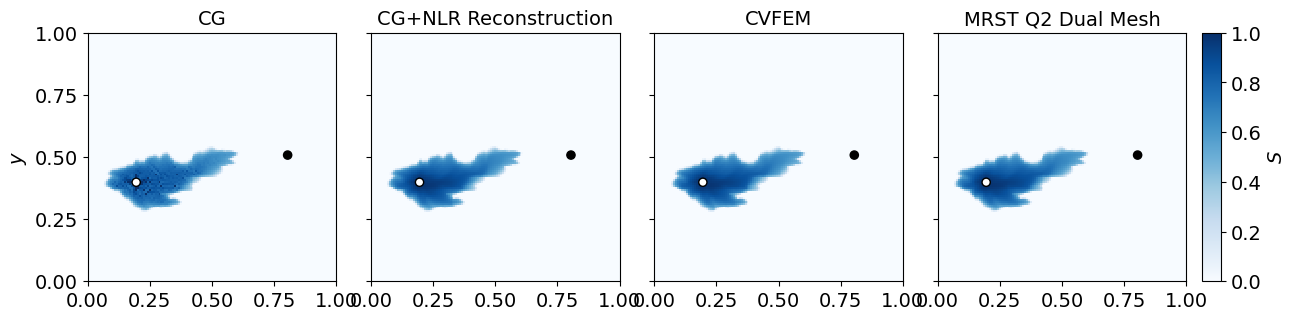

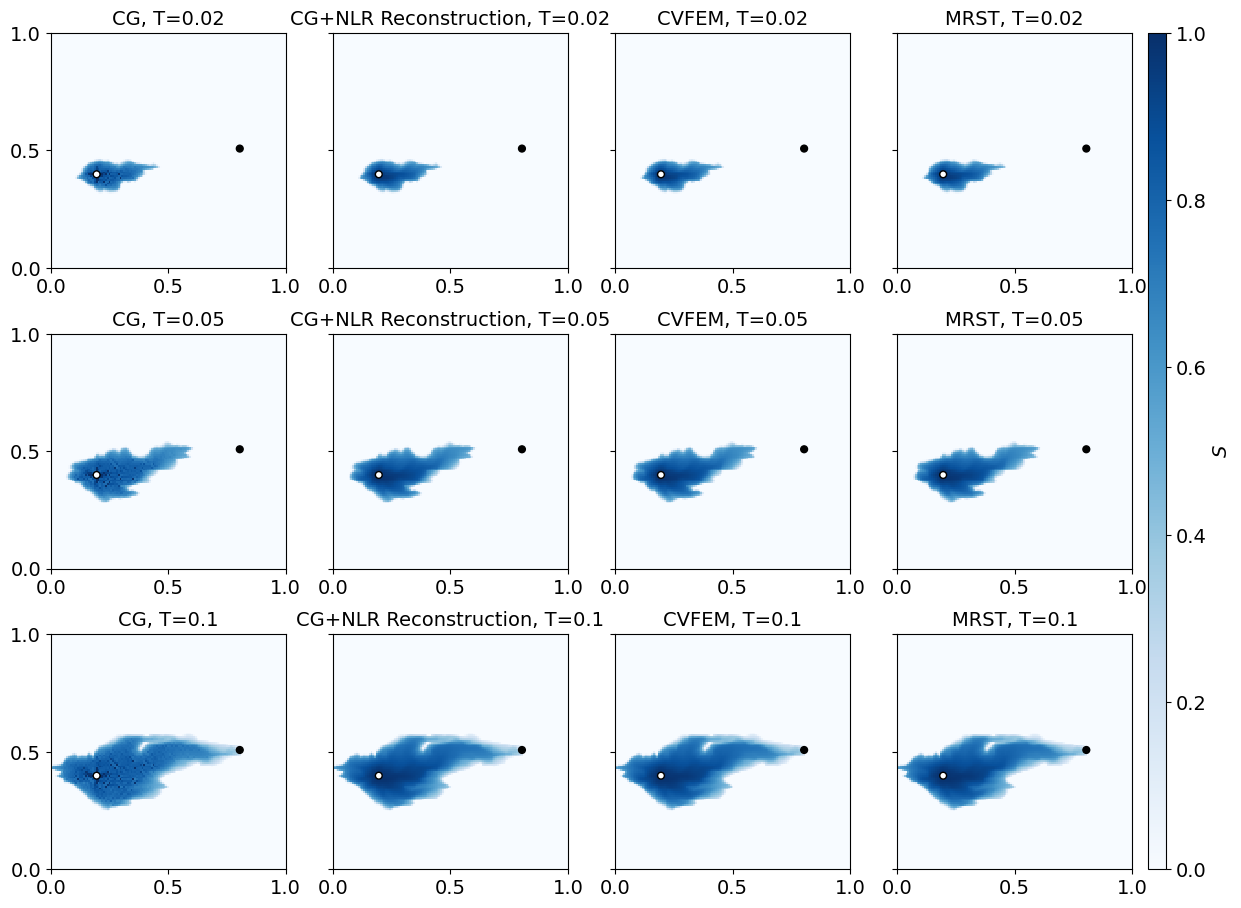

Multi-time saturation comparison plotted for: T=0.02, T=0.05, T=0.1


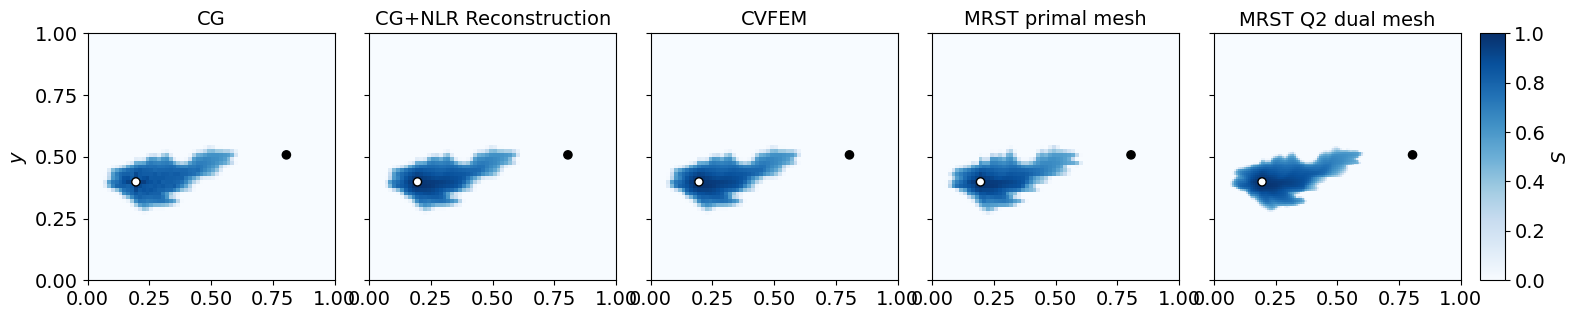

MRST primal rectangular-snapshot comparison at T=5.00000000e-02 using sw_T005_exp (explicitTransport).
  method     mean|e|        RMSE       max|e|
  CG       4.5781e-03  2.1025e-02  2.4557e-01
  NLR      4.0704e-03  1.9730e-02  2.4566e-01
  CVFEM    4.0684e-03  1.9705e-02  2.4505e-01
  MRST primal alternate snapshot (sw_T005 - sw_T005_exp): RMSE=1.2314e-03, max|e|=2.4237e-02
MRST fine/dual-transport snapshot at T=5.00000000e-02 using sw_T005.
  MRST dual-transport dt=5.55247085e-06, cumulative nsteps=9005
Selected case: T0.05, T=5.00000000e-02, PVI=0.050000
Global water mass balance on the Deng Q2 nodal dual mesh:
  method        stored water      boundary net       source term        total net    balance error       clip dM    error%       nsteps       dt
  CG         4.830274e-02     0.000000e+00     5.000000e-02     5.000000e-02  -1.697263e-03 -1.697263e-03 -3.395e+00     8982 5.5667e-06
  NLR        5.000000e-02     0.000000e+00     5.000000e-02     5.000000e-02  -2.581269e-15  0

In [11]:
# Saturation plots and water-balance table on the active Deng Qk nodal dual mesh.
def dual_field_to_grid(field):
    return np.asarray(field, dtype=float).reshape(dual_shape)

x_dual_edges = np.concatenate([[xmin], 0.5 * (x_nodes[:-1] + x_nodes[1:]), [xmax]])
y_dual_edges = np.concatenate([[ymin], 0.5 * (y_nodes[:-1] + y_nodes[1:]), [ymax]])
case_lookup = {key: (tfinal, pvi) for key, tfinal, pvi in transport_cases}
selected_T, selected_PVI = case_lookup[TRANSPORT_CASE_KEY]
plot_methods = list(dual_flux_by_method.keys())
plot_titles = {"CG": "CG", "NLR": "CG+NLR Reconstruction", "CVFEM": "CVFEM", "PINN": "CG+PINN Reconstruction"}


def snapshot_key_for_time(data, T, explicit=False):
    suffix = f"T{int(round(100.0 * float(T))):03d}"
    candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
    for key in candidates:
        if key in data:
            arr = np.asarray(data[key]).reshape(-1)
            if arr.size:
                return key
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            i = int(np.argmin(np.abs(times - float(T))))
            suffix = f"T{int(round(100.0 * float(times[i]))):03d}"
            candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
            for key in candidates:
                if key in data:
                    arr = np.asarray(data[key]).reshape(-1)
                    if arr.size:
                        return key
    return None


MRST_PRIMAL_USE_EXPLICIT_TRANSPORT = True
MRST_DUAL_USE_EXPLICIT_TRANSPORT = True
_mrst_sw_key = snapshot_key_for_time(mrst, selected_T, explicit=MRST_PRIMAL_USE_EXPLICIT_TRANSPORT) if MRST_REFERENCE_AVAILABLE else None
_fine_sw_key = snapshot_key_for_time(mrst_fine, selected_T, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT) if MRST_FINE_AVAILABLE else None

first_plot_entries = []
if RUN_DUAL_TRANSPORT:
    for name in [m for m in ["CG", "NLR", "CVFEM"] if m in plot_methods]:
        first_plot_entries.append({
            "title": plot_titles.get(name, name),
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
            "grid": dual_field_to_grid(transport_results[TRANSPORT_CASE_KEY][name]["S"]),
        })
_first_mrst_dual_for_plot = None
if _fine_sw_key is not None:
    _first_mrst_dual_for_plot = np.asarray(mrst_fine[_fine_sw_key], dtype=float).reshape(-1)
    if _first_mrst_dual_for_plot.size == n_nodes:
        first_plot_entries.append({
            "title": f"MRST Q{CG_ORDER} Dual Mesh",
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
            "grid": dual_field_to_grid(_first_mrst_dual_for_plot),
        })
    else:
        print(f"Skipping MRST dual panel in first figure: expected {n_nodes} Q{CG_ORDER} dual cells, got {_first_mrst_dual_for_plot.size}.")

if first_plot_entries:
    fig_w = max(10.0, 3.25 * len(first_plot_entries))
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(first_plot_entries), figsize=(fig_w, 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, item in zip(axes, first_plot_entries):
            pcm = ax.pcolormesh(item["x_edges"], item["y_edges"], item["grid"], cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_title(item["title"])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$S$")
        plt.show()
else:
    print("No dual-transport saturation fields available to plot.")


# Multi-time saturation comparison.  This uses every time in TRANSPORT_T_VALUES,
# so set that array to the paper times you want before rerunning transport.
time_sweep_methods = [m for m in ["CG", "NLR", "CVFEM"] if m in plot_methods]
time_sweep_has_mrst = False
if _fine_sw_key is not None:
    _mrst_time_keys = {}
    for _key, _tfinal, _pvi in transport_cases:
        _k = snapshot_key_for_time(mrst_fine, _tfinal, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT)
        if _k is not None and np.asarray(mrst_fine[_k]).size == n_nodes:
            _mrst_time_keys[_key] = _k
    time_sweep_has_mrst = all(_key in _mrst_time_keys for _key, _, _ in transport_cases)
else:
    _mrst_time_keys = {}

time_sweep_columns = time_sweep_methods + (["MRST"] if time_sweep_has_mrst else [])
if RUN_DUAL_TRANSPORT and time_sweep_columns and len(transport_cases) > 1:
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        nrows = len(transport_cases)
        ncols = len(time_sweep_columns)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.25 * ncols, 3.15 * nrows), squeeze=False)
        pcm = None
        for irow, (_key, _tfinal, _pvi) in enumerate(transport_cases):
            for icol, _name in enumerate(time_sweep_columns):
                ax = axes[irow, icol]
                if _name == "MRST":
                    _grid = dual_field_to_grid(np.asarray(mrst_fine[_mrst_time_keys[_key]], dtype=float).reshape(-1))
                    _title = f"MRST, T={_tfinal:g}"
                else:
                    _grid = dual_field_to_grid(transport_results[_key][_name]["S"])
                    _title = f"{plot_titles.get(_name, _name)}, T={_tfinal:g}"
                pcm = ax.pcolormesh(x_dual_edges, y_dual_edges, _grid, cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
                ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=24, edgecolors="k", zorder=5)
                ax.set_title(_title)
                ax.set_aspect("equal")
                ax.set_xlim(xmin, xmax)
                ax.set_ylim(ymin, ymax)
                ax.set_xticks([0.0, 0.5, 1.0])
                ax.set_yticks([0.0, 0.5, 1.0])
                ax.grid(False)
                if icol > 0:
                    ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.055, right=0.90, bottom=0.055, top=0.94, wspace=0.12, hspace=0.28)
        fig.canvas.draw()
        pos0 = axes[0, -1].get_position()
        pos1 = axes[-1, -1].get_position()
        cax = fig.add_axes([pos0.x1 + 0.012, pos1.y0, 0.014, pos0.y1 - pos1.y0])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$S$")
        plt.show()
    print("Multi-time saturation comparison plotted for:", ", ".join([f"T={t:g}" for _, t, _ in transport_cases]))
    if not time_sweep_has_mrst:
        print("  MRST column omitted because not every selected time has a matching active-dual snapshot.")
elif RUN_DUAL_TRANSPORT and len(transport_cases) <= 1:
    print("Multi-time saturation comparison skipped: TRANSPORT_T_VALUES has only one time.")


def dual_to_rect_cell_average(S_dual):
    S = np.asarray(S_dual, dtype=float).reshape(-1)
    C = np.zeros(ncell, dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        total = 0.0
        for gi, vid in enumerate(cell["vids"]):
            x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
            subarea = max(0.0, x_r - x_l) * max(0.0, y_t - y_b)
            total += S[int(vid)] * subarea
        C[ci] = total / cell_area[ci]
    return C


def cell_field_to_grid_from_centroids(field, xc, nx_grid, ny_grid, phys=(1.0, 1.0)):
    field = np.asarray(field, dtype=float).reshape(-1)
    xc = np.asarray(xc, dtype=float).reshape(-1, 2)
    hx_grid = float(phys[0]) / int(nx_grid)
    hy_grid = float(phys[1]) / int(ny_grid)
    ix = np.rint((xc[:, 0] - 0.5 * hx_grid) / hx_grid).astype(int)
    iy = np.rint((xc[:, 1] - 0.5 * hy_grid) / hy_grid).astype(int)
    ix = np.clip(ix, 0, int(nx_grid) - 1)
    iy = np.clip(iy, 0, int(ny_grid) - 1)
    grid = np.full((int(ny_grid), int(nx_grid)), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid


def fine_grid_info(data, S=None):
    if "xc_matrix" not in data:
        return None
    xc = np.asarray(data["xc_matrix"], dtype=float).reshape(-1, 2)
    size = int(np.asarray(S).size) if S is not None else int(xc.shape[0])
    if size == n_nodes:
        return {
            "kind": "dual",
            "title": rf"MRST Q{CG_ORDER} dual mesh",
            "xc": xc,
            "nx": dual_nx_nodes,
            "ny": dual_ny_nodes,
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
        }
    n = int(round(np.sqrt(size)))
    return {
        "kind": "uniform",
        "title": rf"MRST mesh ({n}x{n})",
        "xc": xc,
        "nx": n,
        "ny": n,
        "x_edges": np.linspace(0.0, physdim[0], n + 1),
        "y_edges": np.linspace(0.0, physdim[1], n + 1),
    }


def mrst_reference_grid(data, S):
    info = fine_grid_info(data, S)
    if info is None:
        raise ValueError("MRST reference export has no xc_matrix.")
    S = np.asarray(S, dtype=float).reshape(-1)
    if info["kind"] == "dual":
        grid = S.reshape(dual_shape)
    else:
        grid = cell_field_to_grid_from_centroids(S, info["xc"], info["nx"], info["ny"], phys=physdim)
    return info, grid

if (_mrst_sw_key is not None or _fine_sw_key is not None) and RUN_DUAL_TRANSPORT:
    rect_avg_by_method = {name: dual_to_rect_cell_average(transport_results[TRANSPORT_CASE_KEY][name]["S"]) for name in plot_methods}
    comparison_entries = []
    for name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in rect_avg_by_method]:
        comparison_entries.append({
            "title": plot_titles.get(name, name),
            "x_edges": x_edges,
            "y_edges": y_edges,
            "grid": cell_field_to_grid(rect_avg_by_method[name]),
        })
    if _mrst_sw_key is not None:
        mrst_S_rect = _arr(_mrst_sw_key, float).reshape(-1)
        comparison_entries.append({
            "title": "MRST primal mesh",
            "x_edges": x_edges,
            "y_edges": y_edges,
            "grid": cell_field_to_grid(mrst_S_rect),
        })
    else:
        mrst_S_rect = None
    if _fine_sw_key is not None:
        fine_S = np.asarray(mrst_fine[_fine_sw_key], dtype=float).reshape(-1)
        fine_info, fine_grid = mrst_reference_grid(mrst_fine, fine_S)
        fine_xc = fine_info["xc"]
        fine_nx = fine_info["nx"]
        fine_ny = fine_info["ny"]
        fine_x_edges = fine_info["x_edges"]
        fine_y_edges = fine_info["y_edges"]
        comparison_entries.append({
            "title": fine_info["title"],
            "x_edges": fine_x_edges,
            "y_edges": fine_y_edges,
            "grid": fine_grid,
        })
    else:
        fine_S = None

    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(comparison_entries), figsize=(max(13.0, 3.25 * len(comparison_entries)), 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, item in zip(axes, comparison_entries):
            pcm = ax.pcolormesh(item["x_edges"], item["y_edges"], item["grid"], cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_title(item["title"])
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$S$")
        plt.show()

    if _mrst_sw_key is not None:
        _mrst_primal_kind = "explicitTransport" if str(_mrst_sw_key).endswith("_exp") else "hand-code"
        print(f"MRST primal rectangular-snapshot comparison at T={selected_T:.8e} using {_mrst_sw_key} ({_mrst_primal_kind}).")
        print("  method     mean|e|        RMSE       max|e|")
        for name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in rect_avg_by_method]:
            err = rect_avg_by_method[name] - mrst_S_rect
            print(f"  {name:<6} {np.mean(np.abs(err)):12.4e} {np.sqrt(np.mean(err**2)):11.4e} {np.max(np.abs(err)):11.4e}")
        _alt_key = snapshot_key_for_time(mrst, selected_T, explicit=not MRST_PRIMAL_USE_EXPLICIT_TRANSPORT)
        if _alt_key is not None and _alt_key != _mrst_sw_key:
            alt_S = _arr(_alt_key, float).reshape(-1)
            print(f"  MRST primal alternate snapshot ({_alt_key} - {_mrst_sw_key}): RMSE={np.sqrt(np.mean((alt_S-mrst_S_rect)**2)):.4e}, max|e|={np.max(np.abs(alt_S-mrst_S_rect)):.4e}")
    if _fine_sw_key is not None:
        print(f"MRST fine/dual-transport snapshot at T={selected_T:.8e} using {_fine_sw_key}.")
        if fine_S is not None and fine_S.size != n_nodes:
            print(f"  Note: MRST snapshot has {fine_S.size} cells, not the active Q{CG_ORDER} dual size {n_nodes}.")
        if "meta_dt" in mrst_fine and "meta_nsteps" in mrst_fine:
            _times = np.asarray(mrst_fine.get("snap_times", []), dtype=float).reshape(-1)
            _idx = int(np.argmin(np.abs(_times - selected_T))) if _times.size else 0
            _dt = np.asarray(mrst_fine["meta_dt"], dtype=float).reshape(-1)
            _ns = np.asarray(mrst_fine["meta_nsteps"]).reshape(-1)
            if _idx < _dt.size and _idx < _ns.size:
                print(f"  MRST dual-transport dt={_dt[_idx]:.8e}, cumulative nsteps={int(_ns[_idx])}")
else:
    rect_avg_by_method = {}
    mrst_S_rect = None
    fine_S = None
    print("No matching MRST saturation snapshot found for the selected T, or dual transport was skipped.")

print(f"Selected case: {TRANSPORT_CASE_KEY}, T={selected_T:.8e}, PVI={selected_PVI:.6f}")
print(f"Global water mass balance on the Deng Q{CG_ORDER} nodal dual mesh:")
print("  method        stored water      boundary net       source term        total net    balance error       clip dM    error%       nsteps       dt")
if RUN_DUAL_TRANSPORT:
    for name in transport_rect_method_names:
        meta = transport_rect_meta[str(name)]
        boundary_net = meta["water_in"] - meta["water_out"]
        print(
            f"  {str(name):<6} {meta['water_mass']:16.6e} {boundary_net:16.6e} "
            f"{meta['water_source']:16.6e} {meta['water_net']:16.6e} "
            f"{meta['water_balance_error']:14.6e} {meta['clip_mass_delta']:13.6e} "
            f"{meta['water_balance_error_pct']:10.3e} "
            f"{meta['nsteps']:8d} {meta['dt']:10.4e}"
        )
else:
    print("  dual transport skipped")


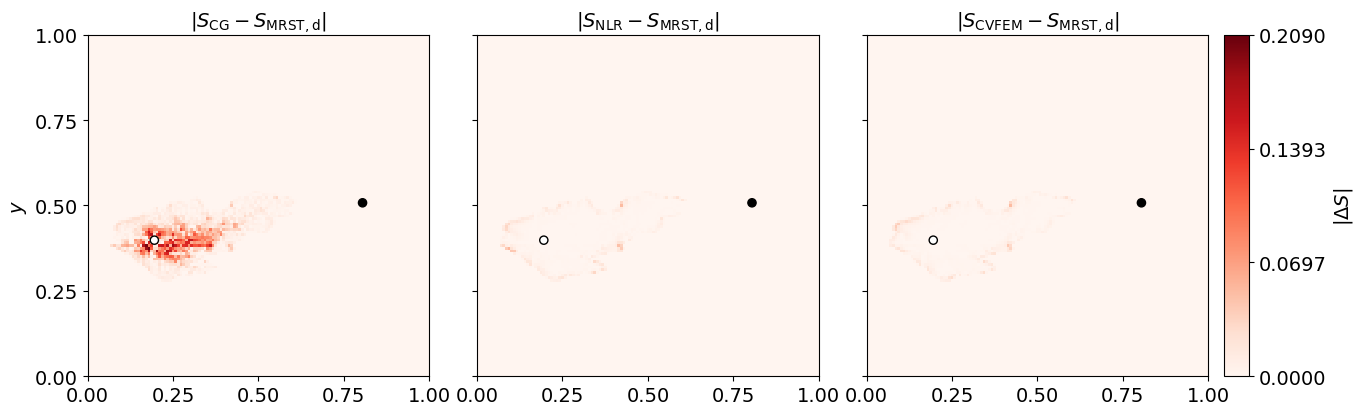

DG0 projection onto common grid (256 x 256):
  reference: MRST dual, snapshot=sw_T005
  method        L2 error       RMSE      max|e|
  CG       1.298466e-02 1.298466e-02 2.089741e-01
  NLR      1.829910e-03 1.829910e-03 5.602063e-02
  CVFEM    1.741259e-03 1.741259e-03 5.275773e-02
  MRST primal vs dual on common grid: L2=3.563120e-02, RMSE=3.563120e-02, max|e|=6.051835e-01


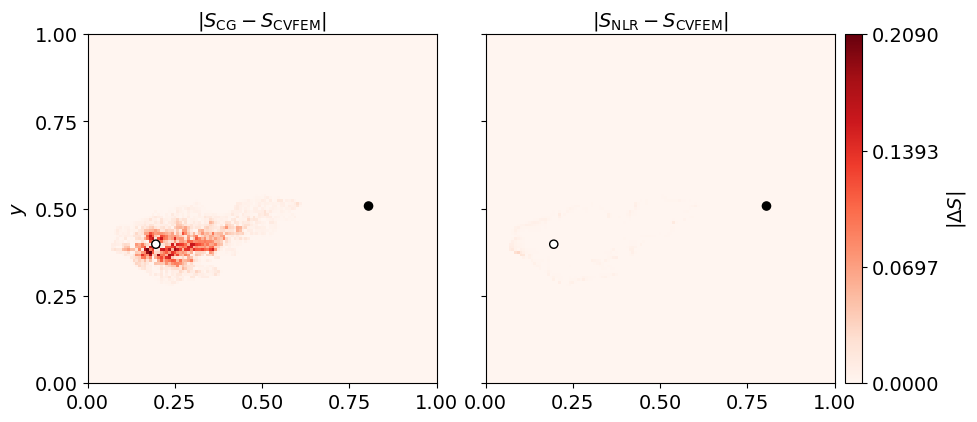

Saturation differences relative to CVFEM on common grid:
  method        L2 error       RMSE      max|e|
  CG-CVFEM     1.288478e-02 1.288478e-02 2.089741e-01
  NLR-CVFEM    6.737017e-04 6.737017e-04 3.330572e-02


In [12]:
# Common DG0 projection for exact saturation-difference maps.
# The common grid resolves both the primal cells and the active Qk nodal-dual CVs.
T_H2_NX = 2 * nx * CG_ORDER
T_H2_NY = 2 * ny * CG_ORDER
T_h2_x_edges = np.linspace(xmin, xmax, T_H2_NX + 1)
T_h2_y_edges = np.linspace(ymin, ymax, T_H2_NY + 1)
T_h2_x_centers = 0.5 * (T_h2_x_edges[:-1] + T_h2_x_edges[1:])
T_h2_y_centers = 0.5 * (T_h2_y_edges[:-1] + T_h2_y_edges[1:])
T_h2_cell_area = float(np.prod(physdim)) / float(T_H2_NX * T_H2_NY)


def project_dual_DG0_to_T_h2(S_dual):
    S_dual_grid = dual_field_to_grid(S_dual)
    ix_dual = np.searchsorted(x_dual_edges, T_h2_x_centers, side="right") - 1
    iy_dual = np.searchsorted(y_dual_edges, T_h2_y_centers, side="right") - 1
    ix_dual = np.clip(ix_dual, 0, dual_nx_nodes - 1)
    iy_dual = np.clip(iy_dual, 0, dual_ny_nodes - 1)
    return S_dual_grid[np.ix_(iy_dual, ix_dual)]


def project_primal_DG0_to_T_h2(S_primal):
    S_grid = cell_field_to_grid(S_primal)
    rep = 2 * CG_ORDER
    return np.repeat(np.repeat(S_grid, rep, axis=0), rep, axis=1)


def project_fine_DG0_to_T_h2(S_fine, fine_xc=None):
    S_fine = np.asarray(S_fine, dtype=float).reshape(-1)
    if S_fine.size == n_nodes:
        return project_dual_DG0_to_T_h2(S_fine)
    if S_fine.size == T_H2_NX * T_H2_NY:
        if fine_xc is None:
            return S_fine.reshape((T_H2_NY, T_H2_NX))
        return cell_field_to_grid_from_centroids(S_fine, fine_xc, T_H2_NX, T_H2_NY, phys=physdim)
    n = int(round(np.sqrt(S_fine.size)))
    if n * n == S_fine.size and fine_xc is not None:
        fine_grid = cell_field_to_grid_from_centroids(S_fine, fine_xc, n, n, phys=physdim)
        x_cent = 0.5 * (np.linspace(xmin, xmax, n + 1)[:-1] + np.linspace(xmin, xmax, n + 1)[1:])
        y_cent = 0.5 * (np.linspace(ymin, ymax, n + 1)[:-1] + np.linspace(ymin, ymax, n + 1)[1:])
        ix = np.searchsorted(np.linspace(xmin, xmax, n + 1), T_h2_x_centers, side="right") - 1
        iy = np.searchsorted(np.linspace(ymin, ymax, n + 1), T_h2_y_centers, side="right") - 1
        ix = np.clip(ix, 0, n - 1)
        iy = np.clip(iy, 0, n - 1)
        return fine_grid[np.ix_(iy, ix)]
    raise ValueError(
        f"Expected active dual size {n_nodes}, common grid size {T_H2_NX*T_H2_NY}, or square fine grid; got {S_fine.size}."
    )

T_h2_fields = {}
if RUN_DUAL_TRANSPORT:
    for _name in plot_methods:
        T_h2_fields[_name] = project_dual_DG0_to_T_h2(transport_results[TRANSPORT_CASE_KEY][_name]["S"])
if _mrst_sw_key is not None and mrst_S_rect is not None:
    T_h2_fields["MRST primal"] = project_primal_DG0_to_T_h2(mrst_S_rect)
if _fine_sw_key is not None and fine_S is not None:
    T_h2_fields["MRST dual"] = project_fine_DG0_to_T_h2(fine_S, fine_xc if 'fine_xc' in globals() else None)

T_H2_ERROR_REFERENCE = "MRST dual" if "MRST dual" in T_h2_fields else "MRST primal"
T_H2_REFERENCE_SNAPSHOT = _fine_sw_key if T_H2_ERROR_REFERENCE == "MRST dual" else _mrst_sw_key
T_H2_ERROR_METHODS = [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in T_h2_fields]
T_H2_LABELS = {
    "CG": r"\mathrm{CG}",
    "NLR": r"\mathrm{NLR}",
    "CVFEM": r"\mathrm{CVFEM}",
    "PINN": r"\theta",
    "MRST primal": r"\mathrm{MRST,p}",
    "MRST dual": r"\mathrm{MRST,d}",
}
T_h2_abs_errors = {}
T_h2_l2_errors = {}
T_h2_rmse_errors = {}
if T_H2_ERROR_REFERENCE in T_h2_fields:
    ref_h2 = T_h2_fields[T_H2_ERROR_REFERENCE]
    for _name in T_H2_ERROR_METHODS:
        err = np.abs(T_h2_fields[_name] - ref_h2)
        T_h2_abs_errors[_name] = err
        T_h2_l2_errors[_name] = float(np.sqrt(np.nansum(err ** 2) * T_h2_cell_area))
        T_h2_rmse_errors[_name] = float(np.sqrt(np.nanmean(err ** 2)))

    _err_vmax = max(float(np.nanmax(v)) for v in T_h2_abs_errors.values()) if T_h2_abs_errors else 1.0
    _err_vmax = _err_vmax if np.isfinite(_err_vmax) and _err_vmax > 0.0 else 1.0e-12
    _ref_label = T_H2_LABELS.get(T_H2_ERROR_REFERENCE, r"\mathrm{MRST}")
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(T_h2_abs_errors), figsize=(4.5 * max(1, len(T_h2_abs_errors)), 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, (_name, _err) in zip(axes, T_h2_abs_errors.items()):
            pcm = ax.pcolormesh(T_h2_x_edges, T_h2_y_edges, _err, cmap="Reds", vmin=0.0, vmax=_err_vmax, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            _lab = T_H2_LABELS.get(_name, rf"\mathrm{{{_name}}}")
            ax.set_title(rf"$|S_{{{_lab}}}-S_{{{_ref_label}}}|$")
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.018, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$|\Delta S|$")
        cbar.set_ticks(np.linspace(0.0, _err_vmax, 4))
        plt.show()

    print(rf"DG0 projection onto common grid ({T_H2_NX} x {T_H2_NY}):")
    print(f"  reference: {T_H2_ERROR_REFERENCE}, snapshot={T_H2_REFERENCE_SNAPSHOT}")
    print("  method        L2 error       RMSE      max|e|")
    for _name, _err in T_h2_abs_errors.items():
        print(f"  {_name:<8} {T_h2_l2_errors[_name]:12.6e} {T_h2_rmse_errors[_name]:10.6e} {np.nanmax(_err):10.6e}")
    if "MRST primal" in T_h2_fields and "MRST dual" in T_h2_fields:
        _mrst_cross = np.abs(T_h2_fields["MRST primal"] - T_h2_fields["MRST dual"])
        _mrst_cross_l2 = float(np.sqrt(np.nansum(_mrst_cross ** 2) * T_h2_cell_area))
        _mrst_cross_rmse = float(np.sqrt(np.nanmean(_mrst_cross ** 2)))
        print(f"  MRST primal vs dual on common grid: L2={_mrst_cross_l2:.6e}, RMSE={_mrst_cross_rmse:.6e}, max|e|={np.nanmax(_mrst_cross):.6e}")
else:
    T_h2_abs_errors = {}
    T_h2_l2_errors = {}
    T_h2_rmse_errors = {}
    print("Skipping common-grid difference map: MRST reference is unavailable.")

T_h2_cvfem_abs_errors = {}
T_h2_cvfem_l2_errors = {}
T_h2_cvfem_rmse_errors = {}
if "CVFEM" in T_h2_fields:
    for _name in [m for m in ["CG", "NLR"] if m in T_h2_fields]:
        err = np.abs(T_h2_fields[_name] - T_h2_fields["CVFEM"])
        T_h2_cvfem_abs_errors[_name] = err
        T_h2_cvfem_l2_errors[_name] = float(np.sqrt(np.nansum(err ** 2) * T_h2_cell_area))
        T_h2_cvfem_rmse_errors[_name] = float(np.sqrt(np.nanmean(err ** 2)))

if T_h2_cvfem_abs_errors:
    _cv_vmax = max(float(np.nanmax(v)) for v in T_h2_cvfem_abs_errors.values())
    _cv_vmax = _cv_vmax if np.isfinite(_cv_vmax) and _cv_vmax > 0.0 else 1.0e-12
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(T_h2_cvfem_abs_errors), figsize=(4.5 * max(1, len(T_h2_cvfem_abs_errors)), 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, (_name, _err) in zip(axes, T_h2_cvfem_abs_errors.items()):
            pcm = ax.pcolormesh(T_h2_x_edges, T_h2_y_edges, _err, cmap="Reds", vmin=0.0, vmax=_cv_vmax, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            _lab = T_H2_LABELS.get(_name, rf"\mathrm{{{_name}}}")
            ax.set_title(rf"$|S_{{{_lab}}}-S_{{\mathrm{{CVFEM}}}}|$")
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.018, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$|\Delta S|$")
        cbar.set_ticks(np.linspace(0.0, _cv_vmax, 4))
        plt.show()

    print("Saturation differences relative to CVFEM on common grid:")
    print("  method        L2 error       RMSE      max|e|")
    for _name, _err in T_h2_cvfem_abs_errors.items():
        print(f"  {_name + '-CVFEM':<12} {T_h2_cvfem_l2_errors[_name]:12.6e} {T_h2_cvfem_rmse_errors[_name]:10.6e} {np.nanmax(_err):10.6e}")


In [10]:
# Save compact diagnostics for paper tables/figures.
OUT_DIR = pathlib.Path(f"result_deng_example4_spe10_Q{CG_ORDER}_no_fracture")
OUT_DIR.mkdir(exist_ok=True)
np.savez(
    OUT_DIR / "diagnostics.npz",
    nx=np.array(nx),
    ny=np.array(ny),
    CG_ORDER=np.array(CG_ORDER),
    dual_shape=np.asarray(dual_shape),
    physdim=physdim,
    xc_matrix=xc_matrix,
    kappa_cell=kappa_cell_dg0,
    source_points_requested=SOURCE_POINTS_REQUESTED,
    source_points_effective=source_points_effective,
    source_cell_ids=source_cell_ids,
    source_rates=SOURCE_RATES,
    source_rate_cell=source_rate_cell,
    p_nodes=p_nodes,
    p_matrix_cg=p_matrix_cg,
    p_nlr_nodes=p_nlr_nodes,
    p_cvfem_nodes=p_cvfem_nodes,
    p_matrix_cvfem=p_matrix_cvfem,
    R_tau_cg=R_tau_cg,
    R_tau_nlr=R_tau_nlr,
    R_xi_cg=R_xi_cg,
    R_xi_nlr=R_xi_nlr,
    R_tau_cvfem=R_tau_cvfem,
    R_xi_cvfem=R_xi_cvfem,
    face_flux_cg=face_flux_cg_global,
    face_flux_nlr=face_flux_nlr_global,
    face_flux_cvfem=face_flux_cvfem_global,
    face_flux_pinn=np.asarray([]) if face_flux_pinn_global is None else face_flux_pinn_global,
    pinn_active=np.array(PINN_ACTIVE),
    transport_method_names=transport_rect_method_names,
    transport_S=transport_rect_S,
    transport_T=np.array(selected_T),
    transport_PVI=np.array(selected_PVI),
    transport_water_mass=transport_rect_water_mass,
    transport_water_net=transport_rect_water_net,
    transport_water_balance_error=transport_rect_water_balance_error,
    transport_water_balance_error_pct=transport_rect_water_balance_error_pct,
    mrst_primal_snapshot_key=np.array(_mrst_sw_key if _mrst_sw_key is not None else ""),
    mrst_primal_use_explicit_transport=np.array(MRST_PRIMAL_USE_EXPLICIT_TRANSPORT if "MRST_PRIMAL_USE_EXPLICIT_TRANSPORT" in globals() else False),
    mrst_fine_snapshot_key=np.array(_fine_sw_key if _fine_sw_key is not None else ""),
    mrst_dual_use_explicit_transport=np.array(MRST_DUAL_USE_EXPLICIT_TRANSPORT if "MRST_DUAL_USE_EXPLICIT_TRANSPORT" in globals() else False),
    mrst_fine_file=np.array(str(FINE_MRST_FILE) if FINE_MRST_FILE is not None else ""),
    mrst_fine_meta_grid=np.array(str(mrst_fine.get("meta_grid", "")) if MRST_FINE_AVAILABLE else ""),
    mrst_fine_meta_workflow=np.array(str(mrst_fine.get("meta_workflow", "")) if MRST_FINE_AVAILABLE else ""),
    mrst_fine_dt=np.asarray(mrst_fine.get("meta_dt", []), dtype=float) if MRST_FINE_AVAILABLE else np.array([]),
    mrst_fine_nsteps=np.asarray(mrst_fine.get("meta_nsteps", [])) if MRST_FINE_AVAILABLE else np.array([]),
    T_h2_l2_error_methods=np.asarray(list(T_h2_l2_errors.keys()), dtype=object) if "T_h2_l2_errors" in globals() else np.asarray([], dtype=object),
    T_h2_l2_errors=np.asarray(list(T_h2_l2_errors.values()), dtype=float) if "T_h2_l2_errors" in globals() else np.asarray([], dtype=float),
    T_h2_rmse_errors=np.asarray([T_h2_rmse_errors[k] for k in T_h2_l2_errors.keys()], dtype=float) if "T_h2_l2_errors" in globals() and "T_h2_rmse_errors" in globals() else np.asarray([], dtype=float),
    T_h2_reference=np.array(T_H2_ERROR_REFERENCE if "T_H2_ERROR_REFERENCE" in globals() else ""),
    T_h2_cvfem_l2_error_methods=np.asarray(list(T_h2_cvfem_l2_errors.keys()), dtype=object) if "T_h2_cvfem_l2_errors" in globals() else np.asarray([], dtype=object),
    T_h2_cvfem_l2_errors=np.asarray(list(T_h2_cvfem_l2_errors.values()), dtype=float) if "T_h2_cvfem_l2_errors" in globals() else np.asarray([], dtype=float),
    T_h2_cvfem_rmse_errors=np.asarray([T_h2_cvfem_rmse_errors[k] for k in T_h2_cvfem_l2_errors.keys()], dtype=float) if "T_h2_cvfem_l2_errors" in globals() and "T_h2_cvfem_rmse_errors" in globals() else np.asarray([], dtype=float),
)
print(f"Saved diagnostics to {OUT_DIR / 'diagnostics.npz'}")


Saved diagnostics to result_deng_example4_spe10_Q2_no_fracture/diagnostics.npz


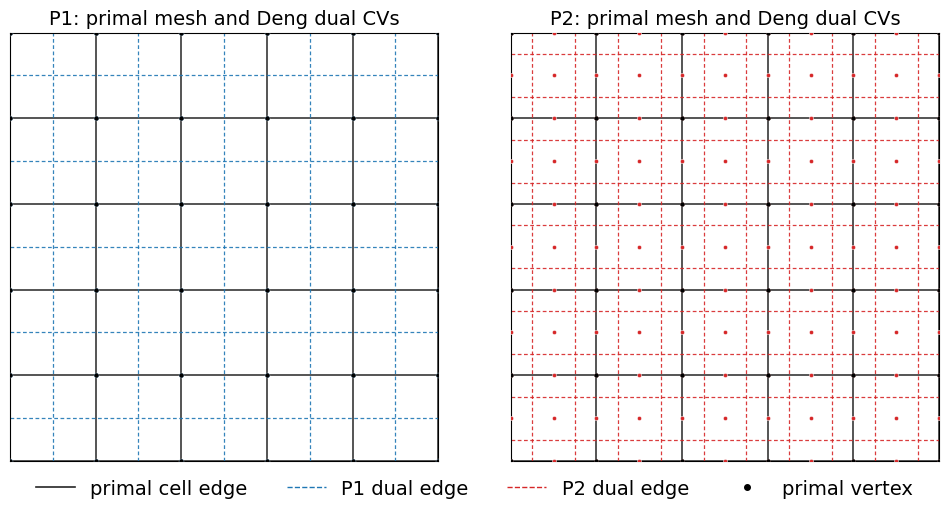

In [17]:
# Visual explanation: primal mesh versus Deng nodal dual meshes for P1 and P2.
# This schematic is zoomed near the injector primal cell so the dual CV structure is readable.
DENG_MESH_SKETCH_AROUND_INJECTOR = True
DENG_MESH_SKETCH_HALF_WIDTH_CELLS = 2
DENG_MESH_SKETCH_SAVE = True


def _dual_edges_from_order(order):
    xq = np.linspace(xmin, xmax, nx * order + 1)
    yq = np.linspace(ymin, ymax, ny * order + 1)
    xd = np.concatenate([[xmin], 0.5 * (xq[:-1] + xq[1:]), [xmax]])
    yd = np.concatenate([[ymin], 0.5 * (yq[:-1] + yq[1:]), [ymax]])
    return xq, yq, xd, yd


def _source_node_indices_for_order(order, cid):
    ix = int(cid % nx)
    iy = int(cid // nx)
    ids = []
    for jj in range(order + 1):
        for ii in range(order + 1):
            ids.append((ix * order + ii, iy * order + jj))
    return ids


inj_cid = int(source_cell_ids[0])
inj_ix = inj_cid % nx
inj_iy = inj_cid // nx
if DENG_MESH_SKETCH_AROUND_INJECTOR:
    pad = int(DENG_MESH_SKETCH_HALF_WIDTH_CELLS)
    ix0 = max(0, inj_ix - pad)
    ix1 = min(nx, inj_ix + pad + 1)
    iy0 = max(0, inj_iy - pad)
    iy1 = min(ny, inj_iy + pad + 1)
else:
    ix0, ix1, iy0, iy1 = 0, min(nx, 5), 0, min(ny, 5)

xlim = (xmin + ix0 * hx, xmin + ix1 * hx)
ylim = (ymin + iy0 * hy, ymin + iy1 * hy)


def _draw_mesh_panel(ax, order, dual_color, title):
    xq, yq, xd, yd = _dual_edges_from_order(order)

    # Primal 64x64 cell edges.
    for i in range(ix0, ix1 + 1):
        x = xmin + i * hx
        ax.plot([x, x], ylim, color="0.15", lw=1.1, zorder=1)
    for j in range(iy0, iy1 + 1):
        y = ymin + j * hy
        ax.plot(xlim, [y, y], color="0.15", lw=1.1, zorder=1)

    # Deng nodal-dual CV edges for the chosen order.
    for x in xd[(xd >= xlim[0] - 1e-14) & (xd <= xlim[1] + 1e-14)]:
        ax.plot([x, x], ylim, color=dual_color, lw=0.9, ls="--", dashes=(3.0, 2.0), alpha=0.9, zorder=2)
    for y in yd[(yd >= ylim[0] - 1e-14) & (yd <= ylim[1] + 1e-14)]:
        ax.plot(xlim, [y, y], color=dual_color, lw=0.9, ls="--", dashes=(3.0, 2.0), alpha=0.9, zorder=2)

    # Qk pressure/transport nodes.
    Xq, Yq = np.meshgrid(xq, yq, indexing="xy")
    mask = (
        (Xq >= xlim[0] - 1e-14) & (Xq <= xlim[1] + 1e-14)
        & (Yq >= ylim[0] - 1e-14) & (Yq <= ylim[1] + 1e-14)
    )
    ax.scatter(Xq[mask], Yq[mask], s=12 if order == 1 else 9, c=dual_color, edgecolors="white", linewidths=0.35, zorder=4)

    # Primal vertices, shown separately because the Q2 dual mesh has extra nodes.
    xp = np.linspace(xmin, xmax, nx + 1)
    yp = np.linspace(ymin, ymax, ny + 1)
    Xp, Yp = np.meshgrid(xp, yp, indexing="xy")
    pmask = (
        (Xp >= xlim[0] - 1e-14) & (Xp <= xlim[1] + 1e-14)
        & (Yp >= ylim[0] - 1e-14) & (Yp <= ylim[1] + 1e-14)
    )
    ax.scatter(Xp[pmask], Yp[pmask], s=20, c="black", marker=".", zorder=6)

    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)


with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 12, "ytick.labelsize": 12}):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
    _draw_mesh_panel(axes[0], 1, "#1f77b4", r"P1: primal mesh and Deng dual CVs")
    _draw_mesh_panel(axes[1], 2, "#d62728", r"P2: primal mesh and Deng dual CVs")

    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color="0.15", lw=1.2, label="primal cell edge"),
        Line2D([0], [0], color="#1f77b4", lw=1.0, ls="--", label="P1 dual edge"),
        Line2D([0], [0], color="#d62728", lw=1.0, ls="--", label="P2 dual edge"),
        Line2D([0], [0], marker=".", color="black", linestyle="none", markersize=8, label="primal vertex"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.11))
    # fig.suptitle("Deng nodal dual control volumes", y=1.02)
    # if DENG_MESH_SKETCH_SAVE:
    #     _mesh_out_dir = OUT_DIR if "OUT_DIR" in globals() else pathlib.Path("result_deng_example4_spe10_mesh_sketch")
    #     _mesh_out_dir.mkdir(exist_ok=True)
    #     fig.savefig(_mesh_out_dir / "deng_q1_q2_dual_mesh_sketch.png", dpi=300, bbox_inches="tight")
    #     print(f"Saved mesh sketch to {_mesh_out_dir / 'deng_q1_q2_dual_mesh_sketch.png'}")
    plt.show()
